# Evaluación Parcial N° 1 — Fundamentos de Deep Learning (DLY0100)
## Clasificación de prendas de vestir con un Perceptrón Multicapa (MLP) sobre Fashion-MNIST

| | |
|---|---|
| **Integrantes** | Benjamin Valderrama A. |
| **Docente** | Marcelo Tapia |
| **Framework** | TensorFlow / Keras |
| **Entorno** | Google Colab |
| **Dataset** | Fashion-MNIST (`keras.datasets.fashion_mnist`) |


---
# 1. Introducción

## 1.1 Descripción del problema

Tenemos que resolver un problema de **clasificación multiclase de imágenes**: dada una fotografía en escala de grises de 28 × 28 píxeles de una prenda o accesorio, el modelo debe predecir a cuál de **10 categorías** pertenece (camiseta, pantalón, suéter, vestido, abrigo, sandalia, camisa, zapatilla, bolso o botín).

Un caso de uso realista es la **clasificación automática de productos en el catálogo de una tienda en línea**: cuando llegan miles de fotos nuevas, un modelo que asigne la categoría reduce el etiquetado manual.

## 1.2 Objetivos

**Objetivo general.** Diseñar, entrenar, evaluar y optimizar una red neuronal artificial de tipo MLP (Perceptrón Multicapa) con TensorFlow/Keras para clasificar imágenes de Fashion-MNIST, justificando técnicamente cada decisión con evidencia experimental.

**Objetivos específicos.**
1. Cargar y preprocesar los datos de forma adecuada para una red neuronal, justificando cada transformación.
2. Analizar el impacto de las **épocas, la tasa de aprendizaje y el tamaño de batch** mediante experimentos controlados (variando un parámetro a la vez).
3. Comparar distintas **funciones de activación y de pérdida** y seleccionar las más adecuadas para el problema.
4. Evaluar el efecto de técnicas de **regularización y optimización** (dropout, L2, batch normalization, early stopping, optimizadores) sobre la estabilidad y la generalización.
5. Ajustar **hiperparámetros de arquitectura** (número de capas y neuronas) y reentrenar con la configuración elegida.
6. Evaluar el modelo final con **accuracy, precision, recall y F1-score**, interpretando los resultados y proponiendo mejoras.

## 1.3 ¿Por qué Fashion-MNIST?

| Criterio | Justificación |
|---|---|
| **Formato conocido** | Mismo formato que MNIST (imágenes 28×28, 10 clases, 60.000 para entrenar y 10.000 para probar). Es el mismo tipo de problema y formato trabajado previamente con MNIST. |
| **Nivel de dificultad** | Es más difícil que MNIST: hay prendas visualmente parecidas (camiseta, camisa, suéter, abrigo). En un ejercicio previo con MNIST, una red pequeña llegó a ~97,7 % de acierto en entrenamiento tras solo 5 épocas; con tan poco margen de mejora sería difícil *ver* las diferencias entre configuraciones. En Fashion-MNIST sí esperamos que decisiones como la función de activación o la regularización se noten. |
| **Costo computacional bajo** | 784 entradas por imagen: un MLP entrena en minutos, incluso sin GPU. Esto nos permite hacer muchos experimentos controlados dentro del plazo. |
| **Disponibilidad y reproducibilidad** | Se carga con una sola línea desde `keras.datasets`; cualquiera que ejecute el notebook obtiene exactamente los mismos datos. |

## 1.4 Diseño experimental (resumen)

- **Tres particiones:** entrenamiento (50.000) para ajustar los pesos, validación (10.000) para *elegir* configuraciones, y test (10.000) que **no se toca** hasta la evaluación final.
- **Experimentos controlados:** en cada experimento cambia **un solo factor**; todo lo demás (datos, semilla, arquitectura, etc.) se mantiene fijo.
- **Métrica principal durante los experimentos:** accuracy y pérdida en validación. **Evaluación final:** accuracy, precision, recall, F1 (macro) y matriz de confusión.

> **Limitación:** un MLP recibe la imagen "aplanada" y por lo tanto no aprovecha que los píxeles vecinos están relacionados. Las redes convolucionales suelen rendir mejor en imágenes, pero quedan fuera de lo solicitado.


---
# 2. Configuración del entorno

**Qué hacemos y por qué:**

- **Importamos** las librerías que usaremos en todo el notebook. `pandas` para tablas, `matplotlib` para gráficos, `scikit-learn` para la partición estratificada (y más adelante para las métricas) y `TensorFlow/Keras` para la red.
- **Fijamos semillas aleatorias.** El entrenamiento de una red neuronal tiene componentes aleatorios (inicialización de pesos, orden de los batches, dropout). Si no fijamos la semilla, dos corridas con la *misma* configuración darían resultados algo distintos y no podríamos saber si una diferencia se debe al cambio que hicimos o al azar. `keras.utils.set_random_seed` fija de una sola vez las semillas de Python, NumPy y del backend de TensorFlow.
- **Definimos `reiniciar_semillas()`**: la llamaremos justo antes de construir cada modelo, de modo que todos los experimentos partan con **los mismos pesos iniciales**. Es una condición necesaria para que la comparación sea justa.

> Aun con semillas fijas puede haber pequeñas diferencias entre CPU y GPU o entre versiones de TensorFlow. Por eso, más adelante (Sección 7) mediremos el ruido entre corridas antes de interpretar diferencias pequeñas.


In [ ]:
# ============================================================
# 2. CONFIGURACIÓN DEL ENTORNO
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from IPython.display import display

# --- Reproducibilidad ---------------------------------------
SEED = 42

def reiniciar_semillas(seed=SEED):
    """Fija las semillas de Python, NumPy y TensorFlow.
    Se llamará antes de construir CADA modelo para que todos partan
    con los mismos pesos iniciales (comparación justa)."""
    keras.utils.set_random_seed(seed)

reiniciar_semillas()

# --- Estilo de gráficos (uniforme en todo el notebook) -------
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# --- Información del entorno ---------------------------------
print("TensorFlow     :", tf.__version__)
print("NumPy          :", np.__version__)
print("GPU disponible :", len(tf.config.list_physical_devices("GPU")) > 0)


TensorFlow     : 2.20.0
NumPy          : 2.1.3
GPU disponible : False


---
# 3. Carga de datos

`keras.datasets.fashion_mnist.load_data()` descarga el dataset (la primera vez) y devuelve **dos tuplas**:

```
(imágenes_train, etiquetas_train), (imágenes_test, etiquetas_test)
```

Llamamos `x_train_full` / `y_train_full` a los 60.000 ejemplos originales de entrenamiento, porque **más adelante los dividiremos** en entrenamiento y validación. El conjunto `x_test` / `y_test` se guarda intacto hasta la evaluación final.

Cada imagen es una matriz de 28 × 28 con enteros `uint8` entre 0 (negro) y 255 (blanco). Cada etiqueta es un entero entre 0 y 9.

Después de cargar hacemos un **control de calidad básico**: formas, tipos de dato, rango de píxeles y que estén las 10 clases.


In [ ]:
# ============================================================
# 3. CARGA DE DATOS
# ============================================================
fashion_mnist = keras.datasets.fashion_mnist
(x_train_full, y_train_full), (x_test, y_test) = fashion_mnist.load_data()

print("x_train_full:", x_train_full.shape, x_train_full.dtype)
print("y_train_full:", y_train_full.shape, y_train_full.dtype)
print("x_test      :", x_test.shape, x_test.dtype)
print("y_test      :", y_test.shape, y_test.dtype)
print(f"Rango de píxeles (train): [{x_train_full.min()}, {x_train_full.max()}]")
print("Etiquetas presentes     :", np.unique(y_train_full))

# --- Control de calidad: si algo no calza, el notebook se detiene aquí ---
assert x_train_full.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert len(x_train_full) == len(y_train_full) and len(x_test) == len(y_test)
assert set(np.unique(y_train_full)) == set(range(10))
assert set(np.unique(y_test)) == set(range(10))
print("\n✔ Control de calidad superado")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train_full: (60000, 28, 28) uint8
y_train_full: (60000,) uint8
x_test      : (10000, 28, 28) uint8
y_test      : (10000,) uint8
Rango de píxeles (train): [0, 255]
Etiquetas presentes     : [0 1 2 3 4 5 6 7 8 9]

✔ Control de calidad superado


**Salida esperada** (si algo es distinto, revisar antes de continuar):

```
x_train_full: (60000, 28, 28) uint8
y_train_full: (60000,) uint8
x_test      : (10000, 28, 28) uint8
y_test      : (10000,) uint8
Rango de píxeles (train): [0, 255]
Etiquetas presentes     : [0 1 2 3 4 5 6 7 8 9]
```


---
# 4. Análisis exploratorio de datos (EDA)

Antes de entrenar hay que **mirar los datos**. Nos interesan cuatro cosas, y cada una respalda una decisión posterior:

| Pregunta | Por qué importa |
|---|---|
| ¿Cómo se ven las imágenes y cuánta variación hay dentro de una misma clase? | Nos da una idea de la dificultad real del problema. |
| ¿Las clases están balanceadas? | Si lo están, el *accuracy* es una métrica razonable; si no, habría que priorizar precision/recall/F1 por clase. |
| ¿Cómo se distribuyen los valores de los píxeles? | Justifica la normalización. |
| ¿Qué clases se parecen entre sí? | Anticipa dónde se equivocará el modelo, algo que se terminará de confirmar con la matriz de confusión en la evaluación final. |


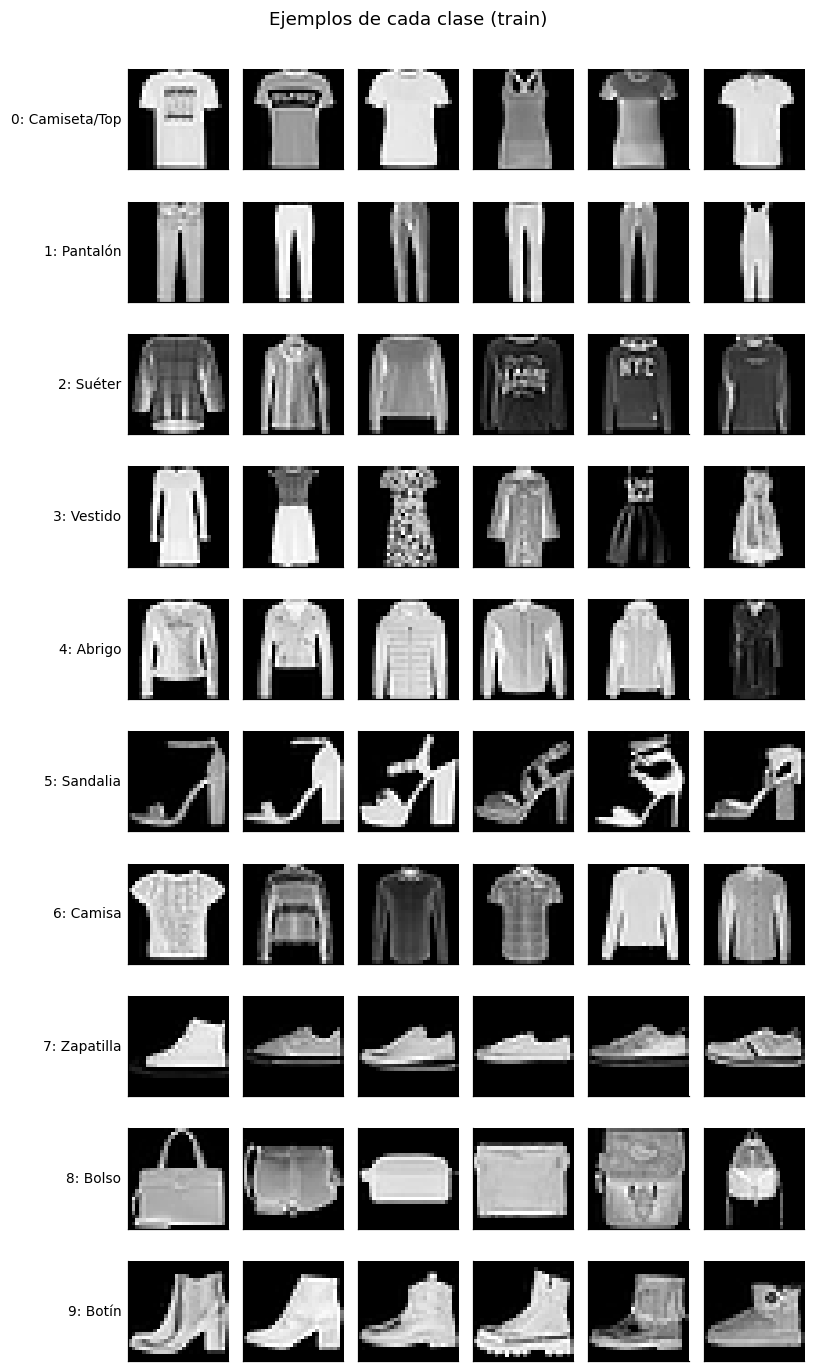

In [ ]:
# ============================================================
# 4.1 Nombres de las clases y mosaico de ejemplos
# ============================================================
NOMBRES_CLASES = ["Camiseta/Top", "Pantalón", "Suéter", "Vestido", "Abrigo",
                  "Sandalia", "Camisa", "Zapatilla", "Bolso", "Botín"]
NUM_CLASES = len(NOMBRES_CLASES)

# 6 ejemplos al azar por clase (con semilla, para que sea reproducible)
rng = np.random.default_rng(SEED)
EJEMPLOS_POR_CLASE = 6

fig, axes = plt.subplots(NUM_CLASES, EJEMPLOS_POR_CLASE, figsize=(7.5, 12.5))
for clase in range(NUM_CLASES):
    idx = rng.choice(np.where(y_train_full == clase)[0], EJEMPLOS_POR_CLASE, replace=False)
    for j, i in enumerate(idx):
        ax = axes[clase, j]
        ax.imshow(x_train_full[i], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if j == 0:
            ax.set_ylabel(f"{clase}: {NOMBRES_CLASES[clase]}", rotation=0,
                          ha="right", va="center", fontsize=9)
fig.suptitle("Ejemplos de cada clase (train)", y=1.0)
plt.tight_layout()
plt.show()


,clase,train (n),train (%),test (n),test (%)
etiqueta,,,,,
0,Camiseta/Top,6000,10.0,1000,10.0
1,Pantalón,6000,10.0,1000,10.0
2,Suéter,6000,10.0,1000,10.0
3,Vestido,6000,10.0,1000,10.0
4,Abrigo,6000,10.0,1000,10.0
5,Sandalia,6000,10.0,1000,10.0
6,Camisa,6000,10.0,1000,10.0
7,Zapatilla,6000,10.0,1000,10.0
8,Bolso,6000,10.0,1000,10.0


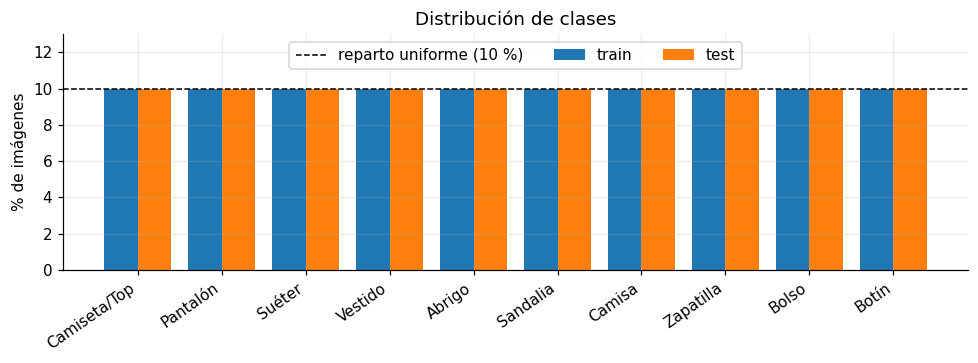

Razón entre la clase más y menos frecuente (train): 1.00


In [ ]:
# ============================================================
# 4.2 Distribución de clases (train y test)
# ============================================================
conteo_train = np.bincount(y_train_full, minlength=NUM_CLASES)
conteo_test = np.bincount(y_test, minlength=NUM_CLASES)

df_dist = pd.DataFrame({
    "clase": NOMBRES_CLASES,
    "train (n)": conteo_train,
    "train (%)": (conteo_train / conteo_train.sum() * 100).round(2),
    "test (n)": conteo_test,
    "test (%)": (conteo_test / conteo_test.sum() * 100).round(2),
})
df_dist.index.name = "etiqueta"
display(df_dist)

fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(NUM_CLASES)
ax.bar(x - 0.2, conteo_train / conteo_train.sum() * 100, width=0.4, label="train")
ax.bar(x + 0.2, conteo_test / conteo_test.sum() * 100, width=0.4, label="test")
ax.axhline(100 / NUM_CLASES, color="k", ls="--", lw=1, label="reparto uniforme (10 %)")
ax.set_xticks(x); ax.set_xticklabels(NOMBRES_CLASES, rotation=35, ha="right")
ax.set_ylabel("% de imágenes"); ax.set_title("Distribución de clases")
ax.set_ylim(0, 13)
ax.legend(ncol=3, loc="upper center")
plt.tight_layout()
plt.show()

print(f"Razón entre la clase más y menos frecuente (train): {conteo_train.max() / conteo_train.min():.2f}")


Media global de los píxeles         : 72.94  (escala 0-255)
Desviación estándar global          : 90.02
Porcentaje de píxeles exactamente 0 : 50.2 %


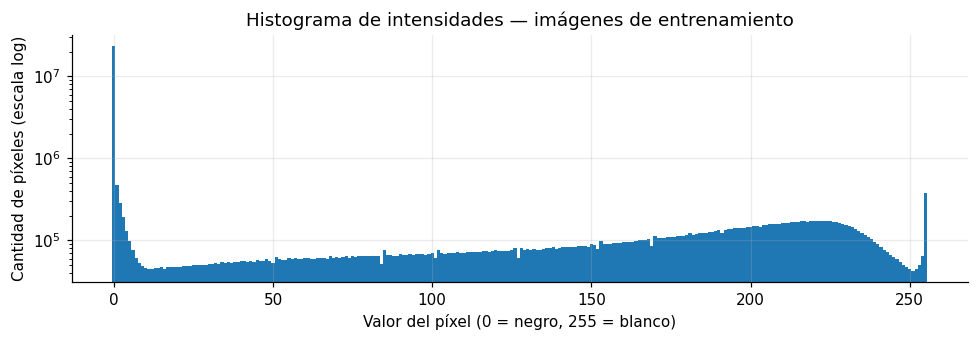

In [ ]:
# ============================================================
# 4.3 Distribución de los valores de píxel
# ============================================================
# np.bincount cuenta cuántos píxeles hay con cada valor 0..255 (exacto y rápido)
conteo_pixeles = np.bincount(x_train_full.ravel(), minlength=256)

media_global = x_train_full.mean()
desv_global = x_train_full.std()
pct_ceros = conteo_pixeles[0] / conteo_pixeles.sum() * 100

print(f"Media global de los píxeles         : {media_global:.2f}  (escala 0-255)")
print(f"Desviación estándar global          : {desv_global:.2f}")
print(f"Porcentaje de píxeles exactamente 0 : {pct_ceros:.1f} %")

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(np.arange(256), conteo_pixeles, width=1.0)
ax.set_yscale("log")
ax.set_xlabel("Valor del píxel (0 = negro, 255 = blanco)")
ax.set_ylabel("Cantidad de píxeles (escala log)")
ax.set_title("Histograma de intensidades — imágenes de entrenamiento")
plt.tight_layout()
plt.show()


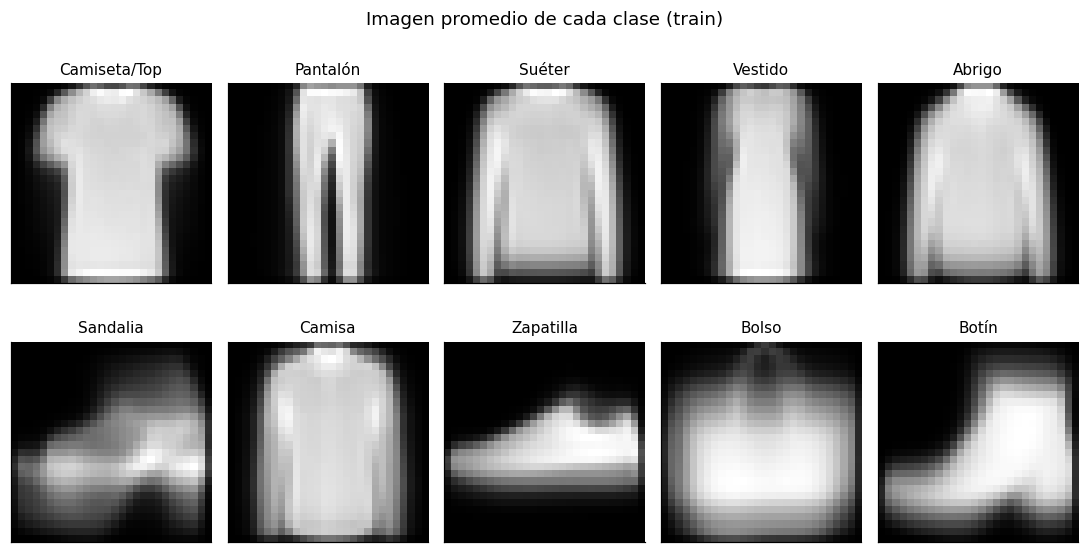

In [ ]:
# ============================================================
# 4.4 Imagen promedio por clase (¿qué clases se parecen?)
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(10, 5.4))
for clase, ax in enumerate(axes.ravel()):
    ax.imshow(x_train_full[y_train_full == clase].mean(axis=0), cmap="gray")
    ax.set_title(NOMBRES_CLASES[clase], fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
fig.suptitle("Imagen promedio de cada clase (train)")
plt.tight_layout(h_pad=2.0)
plt.show()


### 📝 Hallazgos del EDA

**1. Balance de clases → *accuracy* es una métrica válida.**
Las 10 clases tienen exactamente 6.000 imágenes en el conjunto de entrenamiento original y 1.000 en test (10,00 % cada una; razón máx/mín = 1,00). Como no hay clase mayoritaria, adivinar da ≈ 10 % y el accuracy no se "infla" por predecir siempre la clase más común (5.9 lo confirma: 10,0 % también en validación). Aun así, en la evaluación final conviene reportar precision, recall y F1 **por clase**, porque un accuracy global aceptable puede esconder que una clase concreta se confunde mucho. *Dato para la defensa:* en un test perfectamente balanceado el *recall macro* coincide con el accuracy (todas las clases pesan igual); la información nueva la aportan la precision/F1 por clase y la matriz de confusión.

**2. Clases visualmente parecidas** _(hipótesis a contrastar más adelante con la matriz de confusión)_. En las imágenes promedio (4.4):
- **Suéter, Abrigo y Camisa** tienen casi la misma silueta (torso con mangas largas) y **Camiseta/Top** solo se diferencia por las mangas cortas. Distinguirlas depende de detalles finos (cuello, botones, cierre, textura), que un MLP recibe como píxeles sueltos.
- **Pantalón** y **Vestido** comparten una forma vertical alargada.
- **Sandalia, Zapatilla y Botín** forman el grupo del calzado (forma horizontal, más ancha que alta), bien separado de la ropa.
- **Bolso** es la clase de forma más distinta al resto.
- La imagen promedio de **Sandalia** es muy difusa: señal de **alta variabilidad interna**. En el mosaico (4.1) las sandalias aparecen con tacones, plataformas y tiras de formas muy distintas.

**3. Distribución de píxeles → respalda la normalización.**
- **50,2 % de los píxeles vale exactamente 0** (fondo negro): en promedio ≈ 393 de las 784 entradas de cada imagen son cero. Las imágenes son *dispersas*: casi la mitad de las entradas no aporta a la suma ponderada de la primera capa.
- **Media global = 72,94** y **desviación estándar = 90,02** (escala 0–255), es decir ≈ 0,286 y ≈ 0,353 en [0, 1] (coincide con la media 0,2863 de `X_train` en 5.7). Sin normalizar, las entradas llegarían hasta 255 con una desviación de ≈ 90, valores enormes frente a los pesos iniciales, que serán del orden de ±0,08 en la primera capa. Esto respalda la decisión de dividir por 255; lo comprobamos experimentalmente en la Sección 7 (experimentos controlados).
- **Histograma (4.3):** un pico enorme en 0 (≈ 2 × 10⁷ píxeles), luego una meseta de entre ≈ 4 × 10⁴ y 1,7 × 10⁵ píxeles por valor que crece hasta ≈ 220 y cae, y un pico menor en 255 (≈ 4 × 10⁵ píxeles saturados). La distribución **no es gaussiana** (domina el cero): estandarizar centraría los datos, pero no cambiaría esa forma. Con min-max la media queda en ≈ 0,29 (entradas no centradas); se incluye como experimento opcional en la Sección 7.

**4. Variabilidad dentro de las clases (mosaico 4.1).**
Hay bastante variación dentro de una misma clase: *Camiseta/Top* mezcla poleras de manga corta con una de tirantes; *Camisa* incluye prendas que parecen poleras y otras de manga larga; hay prendas muy oscuras (p. ej., un abrigo casi negro) y otras muy claras, así que el brillo y el contraste cambian mucho entre imágenes. El problema no es trivial: el MLP deberá aprender patrones robustos a esos cambios.

**Decisiones de preprocesamiento respaldadas por los datos**

| Decisión | Evidencia observada |
|---|---|
| Partición estratificada 50k/10k/10k | 5.7: diferencia máxima de proporción por clase entre particiones = 0,000 puntos porcentuales; media de `X` similar (0,2863 / 0,2849 / 0,2868). |
| Normalizar a [0, 1] | Píxeles hasta 255, desviación ≈ 90; 50,2 % de ceros. |
| *Accuracy* como métrica principal (más precision/recall/F1 por clase al final) | Clases perfectamente balanceadas; línea base por azar = 10,0 %. |


---
# 5. Preprocesamiento

## 5.1 Resumen de decisiones

| # | Decisión | Qué hacemos | Alternativa considerada |
|---|---|---|---|
| 1 | Partición | 50.000 entrenamiento / 10.000 validación / 10.000 test, estratificada | `validation_split` de Keras; validación cruzada k-fold |
| 2 | Normalización | Dividir por 255 → rango [0, 1] | Estandarización z-score |
| 3 | Tipo de dato | `float32` | `float64` (el resultado por defecto de dividir en NumPy) |
| 4 | Forma de la entrada | Aplanar 28×28 → vector de 784 | Capa `Flatten` dentro del modelo (equivalente) |
| 5 | Etiquetas | One-hot (vectores de 10 posiciones) | Enteros + `sparse_categorical_crossentropy` |

## 5.2 Justificación técnica de cada decisión

**1. Partición estratificada 50k / 10k / 10k.**
Los hiperparámetros (learning rate, arquitectura, regularización…) se *eligen* mirando el desempeño en validación. Si además los evaluáramos en test, habríamos "ajustado" el modelo a esos datos y la nota final sería optimista. Por eso el **test queda intacto** hasta la evaluación final y solo se usa una vez.
- *Estratificada* significa que cada partición conserva la proporción de clases del original. Con datos ya balanceados casi no cambia nada, pero es la práctica correcta y garantiza que la validación sea representativa.
- *Semilla fija* (`random_state=SEED`) → la partición es siempre la misma y **todos los experimentos usan exactamente la misma validación** (condición para compararlos).
- Preferimos una partición explícita antes que `validation_split=0.2` de Keras, porque este último toma los *últimos* ejemplos del arreglo **sin mezclar ni estratificar**, y no nos deja controlar qué datos quedan en cada lado.
- **Validación cruzada:** es más robusta, pero cuesta *k* veces el tiempo de entrenamiento. Con decenas de experimentos por hacer, un *hold-out* fijo es suficiente; si el tiempo alcanza, la aplicaremos solo a la configuración final.
- **Orden:** partimos *antes* de aplicar cualquier transformación que se "ajuste" con los datos (p. ej. calcular una media). Dividir por 255 no aprende nada de los datos, pero adoptamos el hábito correcto para evitar **fuga de información** (*data leakage*).

**2. Normalización a [0, 1] (`x / 255`).**
Los píxeles llegan en [0, 255]. Con entradas tan grandes, las primeras capas producen valores muy altos (con ReLU no hay tope) y la softmax final tiende a saturarse (probabilidades cercanas a 0 o 1), lo que genera gradientes de magnitudes muy desiguales; con descenso de gradiente y una tasa de aprendizaje fija el entrenamiento se vuelve inestable o lento. Llevar todo a [0, 1] deja las entradas en una escala comparable a la de los pesos iniciales. Esta hipótesis la ponemos a prueba con datos reales más adelante (Sección 7), entrenando también sin normalizar.
- *Alternativa:* estandarización z-score (media 0, desviación 1). También es válida, pero exige calcular media y desviación **solo con el conjunto de entrenamiento** y aplicarlas a validación/test. Elegimos min-max porque los píxeles ya están acotados en [0, 255] y es la opción más simple como punto de partida.

**3. `float32`.**
Si dividimos un arreglo `uint8` por `255.0`, NumPy devuelve `float64` (8 bytes por valor). Con 50.000 × 784 valores serían ≈ 314 MB en vez de ≈ 157 MB, y Keras igualmente lo convierte a `float32` internamente. Convertimos una sola vez y de forma explícita.

**4. Aplanado 28×28 → 784.**
Una capa `Dense` recibe un vector por muestra, así que cada imagen pasa a ser un vector de 784 características. Es el costo del MLP: **se pierde la estructura espacial** (la red no "sabe" qué píxeles son vecinos), por eso las redes convolucionales suelen ser superiores en imágenes. Lo hacemos en el preprocesamiento (y no con una capa `Flatten`) para trabajar con una matriz `X` de forma `(N, 784)` fácil de inspeccionar.

**5. Etiquetas *one-hot*.**
La capa de salida tendrá 10 neuronas con softmax (una probabilidad por clase) y `categorical_crossentropy` compara esa distribución con la "distribución objetivo" (1 en la clase correcta, 0 en las demás). Además, la comparación posterior con **MSE** (Sección 8) requiere que el objetivo tenga el mismo tamaño que la salida. La alternativa con etiquetas enteras (`sparse_categorical_crossentropy`) es matemáticamente equivalente y usa menos memoria. **Conservamos también las etiquetas enteras** (`y_train`, `y_val`, `y_test`) porque `scikit-learn` las necesita para la matriz de confusión y las métricas.

## 5.3 Decisiones que descartamos (y por qué)

- **Data augmentation** (p. ej. voltear horizontalmente): posible con prendas, pero añade complejidad y no es lo central de un MLP; la generalización se trabaja con regularización más adelante (Sección 9).
- **Transfer learning / modelos preentrenados:** parten de arquitecturas convolucionales que esperan imágenes RGB de mayor tamaño; este proyecto requiere específicamente un MLP, así que no aplica.


In [ ]:
# ============================================================
# 5.4 Funciones de preprocesamiento (modulares y reutilizables)
# ============================================================
ALTO, ANCHO = 28, 28
NUM_ENTRADAS = ALTO * ANCHO   # 784

def normalizar_y_aplanar(imgs):
    """(N, 28, 28) uint8 en [0, 255]  ->  (N, 784) float32 en [0, 1]."""
    imgs = imgs.astype("float32") / 255.0        # 1) tipo float32 y 2) escala [0, 1]
    return imgs.reshape(len(imgs), NUM_ENTRADAS)  # 3) aplanado

def codificar_etiquetas(etiquetas):
    """(N,) enteros 0..9  ->  (N, 10) one-hot float32."""
    return keras.utils.to_categorical(etiquetas, NUM_CLASES)

# ------------------------------------------------------------
# 5.5 Partición estratificada: 50.000 train / 10.000 validación
#     (el test original de 10.000 imágenes NO se toca)
# ------------------------------------------------------------
x_train_img, x_val_img, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=10_000,
    stratify=y_train_full,     # mantiene la proporción de clases
    random_state=SEED,         # partición reproducible
    shuffle=True,
)
x_test_img = x_test            # alias: las imágenes originales de test

# ------------------------------------------------------------
# 5.6 Aplicar el preprocesamiento a cada partición
#     *_img  -> imágenes originales 28x28 (las usaremos para visualizar)
#     X_*    -> entradas para la red (N, 784) float32 en [0, 1]
#     Y_*    -> etiquetas one-hot (N, 10)
#     y_*    -> etiquetas enteras (para scikit-learn)
# ------------------------------------------------------------
X_train, X_val, X_test = (normalizar_y_aplanar(a) for a in (x_train_img, x_val_img, x_test_img))
Y_train, Y_val, Y_test = (codificar_etiquetas(a) for a in (y_train, y_val, y_test))

print("Preprocesamiento aplicado.")


Preprocesamiento aplicado.


## 5.7 Verificación del preprocesamiento

No basta con *aplicar* el preprocesamiento: hay que **comprobar que quedó bien**. Verificamos (con `assert`, que detiene el notebook si algo falla):

1. Formas, tipo de dato y rango de las entradas.
2. Que las etiquetas *one-hot* suman 1 y equivalen a las etiquetas enteras.
3. Que la partición conservó la proporción de clases.
4. Que aplanar es **reversible** (recuperamos la imagen original sin pérdida).


In [ ]:
# ============================================================
# 5.7 Verificación del preprocesamiento
# ============================================================
def verificar(nombre, X, Y, y):
    assert X.shape[1] == NUM_ENTRADAS,                 f"{nombre}: entradas != 784"
    assert X.dtype == np.float32,                      f"{nombre}: X no es float32"
    assert 0.0 <= X.min() and X.max() <= 1.0,          f"{nombre}: X fuera de [0, 1]"
    assert Y.shape == (len(X), NUM_CLASES),            f"{nombre}: forma de Y incorrecta"
    assert np.allclose(Y.sum(axis=1), 1.0),            f"{nombre}: one-hot no suma 1"
    assert np.array_equal(Y.argmax(axis=1), y),        f"{nombre}: one-hot no coincide con y"
    return {"partición": nombre, "n": len(X), "X (forma)": X.shape, "Y (forma)": Y.shape,
            "X mín": float(X.min()), "X máx": float(X.max()), "X media": round(float(X.mean()), 4)}

resumen = pd.DataFrame([
    verificar("train", X_train, Y_train, y_train),
    verificar("val",   X_val,   Y_val,   y_val),
    verificar("test",  X_test,  Y_test,  y_test),
]).set_index("partición")
display(resumen)

# --- Estratificación: % de cada clase en cada partición -----------------
prop = pd.DataFrame({
    "train": np.bincount(y_train, minlength=NUM_CLASES) / len(y_train),
    "val":   np.bincount(y_val,   minlength=NUM_CLASES) / len(y_val),
    "test":  np.bincount(y_test,  minlength=NUM_CLASES) / len(y_test),
}, index=NOMBRES_CLASES) * 100
display(prop.round(2))
dif_max = (prop.max(axis=1) - prop.min(axis=1)).max()
print(f"Máxima diferencia de proporción de una clase entre particiones: {dif_max:.3f} puntos porcentuales")

# --- Aplanar es reversible ---------------------------------------------
img0 = x_train_full[0]
vec0 = normalizar_y_aplanar(x_train_full[:1])[0]
assert np.allclose(vec0.reshape(ALTO, ANCHO) * 255.0, img0), "Aplanar/normalizar no es reversible"
print("\n✔ Todas las verificaciones superadas")


,n,X (forma),Y (forma),X mín,X máx,X media
partición,,,,,,
train,50000,"(50000, 784)","(50000, 10)",0.0,1.0,0.2863
val,10000,"(10000, 784)","(10000, 10)",0.0,1.0,0.2849
test,10000,"(10000, 784)","(10000, 10)",0.0,1.0,0.2868


,train,val,test
Camiseta/Top,10.0,10.0,10.0
Pantalón,10.0,10.0,10.0
Suéter,10.0,10.0,10.0
Vestido,10.0,10.0,10.0
Abrigo,10.0,10.0,10.0
Sandalia,10.0,10.0,10.0
Camisa,10.0,10.0,10.0
Zapatilla,10.0,10.0,10.0
Bolso,10.0,10.0,10.0
Botín,10.0,10.0,10.0


Máxima diferencia de proporción de una clase entre particiones: 0.000 puntos porcentuales

✔ Todas las verificaciones superadas


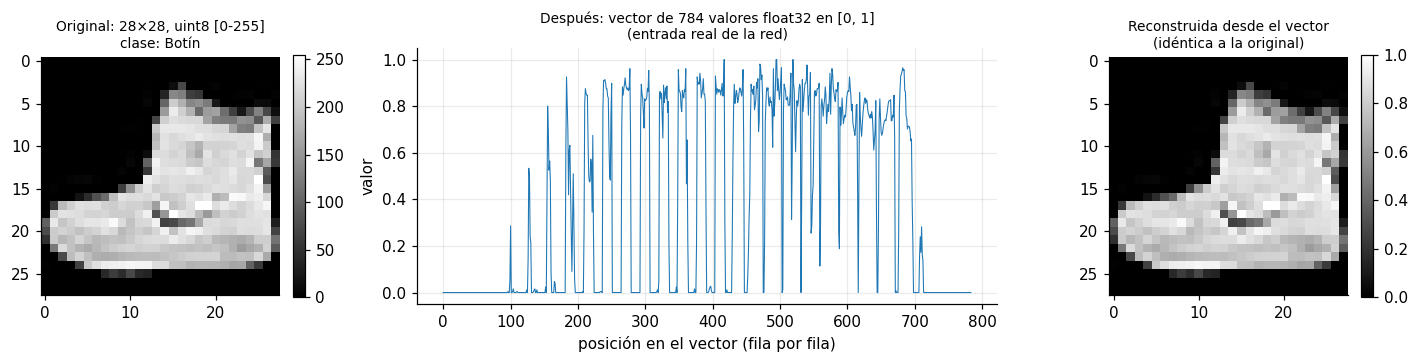

In [ ]:
# ============================================================
# 5.8 Antes y después del preprocesamiento (una imagen)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), gridspec_kw={"width_ratios": [1, 2.2, 1]})

im = axes[0].imshow(img0, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original: 28×28, uint8 [0-255]\nclase: {NOMBRES_CLASES[y_train_full[0]]}", fontsize=9)
axes[0].grid(False); plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].plot(vec0, lw=0.7)
axes[1].set_title("Después: vector de 784 valores float32 en [0, 1]\n(entrada real de la red)", fontsize=9)
axes[1].set_xlabel("posición en el vector (fila por fila)"); axes[1].set_ylabel("valor")

im = axes[2].imshow(vec0.reshape(ALTO, ANCHO), cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Reconstruida desde el vector\n(idéntica a la original)", fontsize=9)
axes[2].grid(False); plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()


## 5.9 Valores de referencia (líneas base) para interpretar los resultados

Antes de entrenar conviene saber **qué resultado tendría un modelo que no aprendió nada**, para no confundir un número "que parece alto" con un buen desempeño:

- **Accuracy por azar:** con 10 clases balanceadas, adivinar da ≈ 10 %. Cualquier modelo que quede cerca de ese valor no está aprendiendo.
- **Pérdida inicial esperada:** una red recién inicializada asigna probabilidades casi uniformes (0,1 por clase); su *cross-entropy* es `−ln(0,1) = ln(10) ≈ 2,3026`. Si al comenzar a entrenar vemos una pérdida muy distinta, hay que sospechar de un error en los datos o en la red. Es el comportamiento esperado para cualquier red sin entrenar en un problema de 10 clases: pérdida cercana a 2,3 y acierto cercano al azar.


In [ ]:
# ============================================================
# 5.9 Líneas base
# ============================================================
acc_azar = 1 / NUM_CLASES
perdida_inicial = np.log(NUM_CLASES)
acc_clase_mayoritaria_val = np.bincount(y_val).max() / len(y_val)

print(f"Accuracy esperada por azar                     : {acc_azar:.1%}")
print(f"Accuracy de predecir siempre la clase más común: {acc_clase_mayoritaria_val:.1%} (en validación)")
print(f"Cross-entropy inicial esperada (ln 10)         : {perdida_inicial:.4f}")


Accuracy esperada por azar                     : 10.0%
Accuracy de predecir siempre la clase más común: 10.0% (en validación)
Cross-entropy inicial esperada (ln 10)         : 2.3026


---
# 6. Modelo base (MLP)

Esta sección define el **modelo de referencia**: una red simple, con hiperparámetros razonables pero **sin ajustar**. Cumple dos funciones:

1. Demostrar que el flujo completo funciona (datos → red → entrenamiento → curvas).
2. Servir de **punto de comparación** para todo lo que sigue. En las siguientes secciones cambiaremos **un elemento a la vez** y mediremos cuánto mejora o empeora respecto de este modelo.

## 6.1 Notación

- $X$: entrada, un vector de $F = 784$ características (los píxeles).
- $h^{i}$: salida de la capa oculta $i$; $L$: cantidad de capas ocultas (aquí $L = 2$); se define $h^{0} = X$.
- $W^{i}, b^{i}$: pesos y sesgo (*bias*) de la capa oculta $i$; $f^{i}$: su función de activación.
- $U, c$: pesos y sesgo de la capa de salida; $g$: función de salida; $C = 10$ neuronas de salida.
- $\theta = \{W^{i}, b^{i}, U, c\}$: **todos los parámetros** de la red. Entrenar significa encontrar el $\theta$ que minimiza la función de error $\mathcal{L}$.

$$h^{i} = f^{i}\!\left(W^{i}\,h^{i-1} + b^{i}\right), \qquad \hat{y} = g\!\left(U\,h^{L} + c\right)$$

> En Keras los datos se organizan por filas: para un lote de $n$ imágenes, cada capa calcula `activación(X @ W + b)`, con `W` de forma `(entradas, neuronas)`. Es la misma fórmula aplicada a un lote completo.

## 6.2 Arquitectura

$$784 \;\xrightarrow{\text{ReLU}}\; 128 \;\xrightarrow{\text{ReLU}}\; 64 \;\xrightarrow{\text{softmax}}\; 10$$

| Capa | Tipo | Forma de salida | Activación | Parámetros | Total |
|---|---|---|---|---|---|
| Entrada | vector $X$ | (lote, 784) | — | — | 0 |
| Oculta 1 | `Dense(128)` | (lote, 128) | ReLU | 784 · 128 + 128 | 100.480 |
| Oculta 2 | `Dense(64)` | (lote, 64) | ReLU | 128 · 64 + 64 | 8.256 |
| Salida | `Dense(10)` | (lote, 10) | softmax | 64 · 10 + 10 | 650 |
| | | | | **Total** | **109.386** |

### Justificación de cada decisión

**Entrada de 784 y salida de 10 neuronas: no se eligen, se derivan del problema.** Cada imagen aplanada tiene 784 valores y hay 10 clases; la salida tiene una neurona por clase.

**Salida con softmax.** Es una clasificación con clases **mutuamente excluyentes** (una prenda es una sola cosa). La función de salida debe garantizar dos cosas: que todos los valores estén entre 0 y 1 y que sumen 1, para poder leer la salida como una **distribución de probabilidad** sobre las clases. Softmax lo hace: con $z = U h^{L} + c$,

$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}$$

ReLU o sigmoide en la salida no garantizarían que las probabilidades sumen 1.

**Pérdida: entropía cruzada categórica (*categorical cross-entropy*).** Para una imagen con etiqueta *one-hot* $y$ y salida $\hat{y}$:

$$\mathcal{L}(y, \hat{y}) = -\sum_{k=1}^{C} y_k \log \hat{y}_k \;=\; -\log \hat{y}_{\text{clase correcta}}$$

Solo cuenta la probabilidad asignada a la clase correcta: vale 0 si le asigna 1 y crece sin límite si le asigna casi 0. La **pérdida** (*loss*) que ve el entrenamiento es el promedio de este error sobre los ejemplos. Si la red reparte probabilidad uniforme (0,1 por clase), $\mathcal{L} = -\log 0{,}1 = \ln 10 \approx 2{,}30$, el valor de referencia calculado en 5.9. Softmax + entropía cruzada es la pareja estándar en clasificación; más adelante (Sección 8) la comparamos empíricamente con MSE.

**Capas ocultas con ReLU**, $f(z) = \max(0, z)$. Necesitamos una activación **no lineal**: sin ella, apilar capas equivale a una sola transformación lineal y la red no ganaría capacidad. ReLU es barata de calcular y, para $z > 0$, su derivada vale 1 (no "achata" el gradiente como las sigmoides en sus extremos). Es el punto de partida habitual; más adelante (Sección 8) la comparamos con tanh y sigmoide con datos propios.

**Dos capas ocultas de 128 y 64 neuronas.** **No existe una fórmula cerrada** para decidir cuántas capas ni cuántas neuronas usar; más neuronas y más capas aumentan drásticamente los parámetros y el tiempo de entrenamiento. Elegimos un tamaño moderado en forma de "embudo" (784 → 128 → 64 → 10) como **punto de partida**, no como valor óptimo. Tiene 109.386 parámetros para 50.000 ejemplos de entrenamiento (≈ 2 parámetros por ejemplo): capacidad suficiente para aprender y, a la vez, riesgo real de sobreajuste, que vigilaremos con la brecha entrenamiento–validación. El ajuste fino de esta arquitectura (número de capas y neuronas) queda como una etapa posterior del proyecto.

**Inicialización.** Keras inicializa los pesos de cada `Dense` con la distribución *Glorot uniform* y los sesgos en 0. Los pesos deben partir con valores pequeños y **distintos** entre sí: si todos fueran iguales, todas las neuronas de una capa aprenderían lo mismo. Por eso la semilla es importante (Sección 2).


In [ ]:
# ============================================================
# 6.3 Implementación del modelo (funciones reutilizables)
# ============================================================
import time

def construir_modelo(unidades=(128, 64), activacion="relu", nombre="mlp_base", salida="softmax"):
    """MLP totalmente conectado: NUM_ENTRADAS -> unidades... -> NUM_CLASES (softmax).

    unidades   : tupla con la cantidad de neuronas de cada capa oculta.
    activacion : función de activación de las capas ocultas.
    salida     : función de salida de la última capa (por defecto softmax).
    """
    modelo = keras.Sequential(name=nombre)
    modelo.add(keras.Input(shape=(NUM_ENTRADAS,), name="entrada"))      # F = 784
    for k, u in enumerate(unidades, start=1):
        modelo.add(keras.layers.Dense(u, activation=activacion, name=f"oculta_{k}"))
    modelo.add(keras.layers.Dense(NUM_CLASES, activation=salida, name="salida"))  # C = 10
    return modelo

def contar_parametros(unidades, entradas=NUM_ENTRADAS, clases=NUM_CLASES):
    """Parámetros de una red densa: por cada capa, (entradas*neuronas) pesos + neuronas sesgos."""
    tamanos = [entradas, *unidades, clases]
    return sum(a * b + b for a, b in zip(tamanos[:-1], tamanos[1:]))

# --- Construimos el modelo base y verificamos el conteo de parámetros ---
reiniciar_semillas()
modelo_demo = construir_modelo()
modelo_demo.summary()

esperado = contar_parametros((128, 64))
print(f"\nParámetros según la fórmula: {esperado:,} | según Keras: {modelo_demo.count_params():,}")
assert modelo_demo.count_params() == esperado == 109_386
print("✔ El conteo de parámetros coincide con el cálculo manual")


Model: "mlp_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Parámetros según la fórmula: 109,386 | según Keras: 109,386
✔ El conteo de parámetros coincide con el cálculo manual


## 6.4 Compilación y configuración de entrenamiento base

Antes de entrenar hay que decir **cómo** se entrena: qué pérdida minimizar, con qué algoritmo y con qué hiperparámetros.

### Algoritmo: descenso de gradiente estocástico *mini-batch* (SGD)

En cada iteración el algoritmo:
1. toma un **lote** (*batch*) de ejemplos **al azar**,
2. estima el error promedio sobre ese lote,
3. calcula el gradiente de la pérdida respecto de $\theta$ y **da un paso en sentido contrario** al gradiente: $\theta \leftarrow \theta - \lambda \, \nabla_{\theta}\mathcal{L}$, donde $\lambda$ es la **tasa de aprendizaje**.

Se usa un lote y no todos los datos porque calcular el error con todos los ejemplos en cada paso es demasiado caro para redes con miles o millones de parámetros; lo esencial es que el lote sea al azar. Por eso `fit` **mezcla** los datos en cada época (`shuffle=True`).

Vocabulario que usaremos en todo el notebook:

| Término | Significado | Valor en el modelo base |
|---|---|---|
| **Iteración** | una actualización de $\theta$ con un lote | — |
| **Época** | una pasada completa por los 50.000 ejemplos de entrenamiento | 20 épocas |
| **Tamaño de lote** | ejemplos por iteración | 64 |
| **Iteraciones por época** | $\lceil 50.000 / 64 \rceil$ | 782 |
| **Total de actualizaciones** | épocas × iteraciones por época | 15.640 |

### Hiperparámetros base y cómo los estudiaremos

| Hiperparámetro | Valor base | Justificación | Se estudia en |
|---|---|---|---|
| **Optimizador** | SGD *mini-batch*, sin *momentum* | Algoritmo estándar de referencia; permite comparar después contra otros optimizadores. | Sección 9 |
| **Tasa de aprendizaje** $\lambda$ | 0,01 | Valor por defecto de Keras para SGD y punto de partida habitual. Si es demasiado grande el algoritmo "se pasa" del mínimo y puede no converger; si es demasiado pequeña converge, pero con muchos más pasos de los necesarios. | Sección 7 |
| **Tamaño de lote** | 64 | Compromiso entre estimar bien el gradiente y actualizar seguido. Con un lote de 1 habría decenas de miles de actualizaciones por época y cada una tardaría mucho más; con un lote muy grande, muy pocas actualizaciones por época. Con 64 el costo por época es bajo y hay cientos de actualizaciones. | Sección 7 |
| **Épocas** | 20 | Suficiente para ver la curva de aprendizaje subir y detectar si se aplana o si aparece sobreajuste, sin un costo alto. **No sabemos aún si 20 es suficiente**; es lo que se estudia. | Sección 7 |
| **Pérdida** | `categorical_crossentropy` | Ver 6.2. | Sección 8 |
| **Activación oculta** | ReLU | Ver 6.2. | Sección 8 |
| **Arquitectura** | 128 → 64 | Ver 6.2. | Etapa posterior |
| **Métrica** | *accuracy* | Válida por el balance de clases (hallazgo 1 del EDA). | Evaluación final |

> Estos valores son un **punto de partida razonable, no una configuración ajustada**. Es probable que 20 épocas de SGD con $\lambda = 0{,}01$ no alcancen a converger; es una **hipótesis** que las curvas confirmarán o descartarán.


In [ ]:
# ============================================================
# 6.5 Compilación, entrenamiento y registro de experimentos
# ============================================================
import json, os

# Hiperparámetros base (ver tabla 6.4). Se definen UNA vez, como constantes.
LR_BASE = 0.01
BATCH_BASE = 64
EPOCAS_BASE = 20

def compilar_modelo(modelo, lr=LR_BASE, perdida="categorical_crossentropy"):
    """Asocia al modelo el optimizador (SGD), la pérdida y la métrica.

    La métrica es SIEMPRE el accuracy categórico (clase con mayor salida = clase real).
    Se declara explícitamente porque con metrics=["accuracy"] Keras elige la versión
    según la pérdida (p. ej. con binary_crossentropy usaría accuracy binario, que no
    mide lo que queremos)."""
    modelo.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr),
        loss=perdida,
        metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")],
    )
    return modelo

# Registro de experimentos: nombre -> configuración, historia y tiempo.
# Las partes siguientes lo reutilizan para armar tablas y gráficos comparativos.
# (Si la celda se vuelve a ejecutar en la misma sesión, el registro NO se borra.)
RESULTADOS = globals().get("RESULTADOS", {})
ARCHIVO_RESULTADOS = "resultados_ep1.json"

def guardar_resultados(ruta=ARCHIVO_RESULTADOS):
    """Guarda todos los experimentos en un archivo JSON (descargable desde el panel de archivos de Colab)."""
    with open(ruta, "w", encoding="utf-8") as f:
        json.dump(RESULTADOS, f, default=float)
    print(f"✔ {len(RESULTADOS)} experimentos guardados en {ruta}")

def cargar_resultados(ruta=ARCHIVO_RESULTADOS):
    """Recupera experimentos guardados (útil si Colab reinició la sesión)."""
    with open(ruta, encoding="utf-8") as f:
        guardados = json.load(f)
    for nombre, r in guardados.items():
        r["config"]["unidades"] = tuple(r["config"]["unidades"])
        RESULTADOS[nombre] = r
    print(f"↺ {len(guardados)} experimentos cargados desde {ruta} (no se vuelven a entrenar)")

if os.path.exists(ARCHIVO_RESULTADOS):
    cargar_resultados()

def entrenar(nombre, unidades=(128, 64), activacion="relu", lr=LR_BASE,
             batch_size=BATCH_BASE, epocas=EPOCAS_BASE,
             perdida="categorical_crossentropy", semilla=SEED,
             datos=None, callbacks=None, salida="softmax", verbose=2):
    """Construye, compila y entrena un modelo desde cero.
    Entrena con (X_train, Y_train) y monitorea (X_val, Y_val). El test NO se usa aquí.

    semilla   : semilla de la corrida (por defecto la misma en todos los experimentos).
    datos     : opcional, tupla (X_tr, Y_tr, X_va, Y_va) para usar otra versión de los
                datos (p. ej. sin normalizar). Por defecto se usan las particiones estándar.
    callbacks : lista opcional de callbacks de Keras (p. ej. TerminateOnNaN).
    salida    : función de salida de la última capa (por defecto softmax).
    """
    reiniciar_semillas(semilla)                            # mismos pesos iniciales en todos los experimentos
    modelo = construir_modelo(unidades, activacion, nombre, salida)
    compilar_modelo(modelo, lr, perdida)
    X_tr, Y_tr, X_va, Y_va = datos if datos is not None else (X_train, Y_train, X_val, Y_val)
    t0 = time.perf_counter()
    hist = modelo.fit(
        X_tr, Y_tr,
        validation_data=(X_va, Y_va),
        epochs=epocas,
        batch_size=batch_size,
        shuffle=True,                                      # lotes al azar en cada época
        callbacks=callbacks or [],
        verbose=verbose,
    )
    duracion = time.perf_counter() - t0
    RESULTADOS[nombre] = {
        "config": dict(unidades=unidades, activacion=activacion, salida=salida, lr=lr,
                       batch_size=batch_size, epocas=epocas, perdida=perdida,
                       semilla=semilla, datos="estándar" if datos is None else "alternativos"),
        "historia": hist.history,
        "tiempo_s": duracion,
        "iter_por_epoca": int(np.ceil(len(X_tr) / batch_size)),
    }
    return modelo

def resumir(nombre):
    """Métricas clave de un experimento (una fila de la tabla comparativa)."""
    r = RESULTADOS[nombre]
    h = r["historia"]
    n_ep = len(h["loss"])
    return {
        "experimento": nombre,
        "acc train (final)": h["accuracy"][-1],
        "acc val (final)": h["val_accuracy"][-1],
        "mejor acc val": max(h["val_accuracy"]),
        "época del mejor val": int(np.argmax(h["val_accuracy"])) + 1,
        "pérdida train (final)": h["loss"][-1],
        "pérdida val (final)": h["val_loss"][-1],
        "brecha acc (train - val)": h["accuracy"][-1] - h["val_accuracy"][-1],
        "tiempo total (s)": r["tiempo_s"],
        "s / época": r["tiempo_s"] / n_ep,
    }

def tabla_resumen(nombres):
    return pd.DataFrame([resumir(n) for n in nombres]).set_index("experimento").round(4)

def graficar_curvas(nombres, titulo="Curvas de aprendizaje", solo_val=False, eje="epoca",
                    etiquetas=None, ylim_perdida=None, marcas_epoca=None,
                    paneles=("perdida", "accuracy"), ylim_acc=None):
    """Curvas por época. Línea punteada = train, línea continua = validación.

    solo_val     : True -> dibuja únicamente validación (menos saturado al comparar varias curvas).
    eje          : "epoca" o "actualizaciones" (época x iteraciones por época).
    etiquetas    : dict opcional nombre -> texto de la leyenda.
    ylim_perdida : (mín, máx) opcional para el eje de la pérdida.
    ylim_acc     : (mín, máx) opcional para el eje del accuracy (acerca la vista cuando las curvas son parecidas).
    marcas_epoca : lista opcional de épocas donde dibujar una línea vertical.
    paneles      : ("perdida", "accuracy"), o solo uno de ellos (útil cuando las pérdidas
                   de los modelos comparados no son comparables entre sí).
    """
    claves = {"perdida": ("loss", "val_loss", "Pérdida"),
              "accuracy": ("accuracy", "val_accuracy", "Accuracy")}
    fig, axs = plt.subplots(1, len(paneles), figsize=(6 * len(paneles), 4))
    axs = np.atleast_1d(axs)
    for ax, panel in zip(axs, paneles):
        k_tr, k_va, nombre_panel = claves[panel]
        for k, nombre in enumerate(nombres):
            r = RESULTADOS[nombre]
            h = r["historia"]
            x = np.arange(1, len(h[k_tr]) + 1)
            if eje == "actualizaciones":
                x = x * r["iter_por_epoca"]
            c = f"C{k}"
            et = (etiquetas or {}).get(nombre, nombre)
            if not solo_val:
                ax.plot(x, h[k_tr], "--", color=c, alpha=0.65, label=f"{et} (train)")
            ax.plot(x, h[k_va], "-", color=c, label=et if solo_val else f"{et} (val)")
        if panel == "accuracy":
            ax.axhline(1 / NUM_CLASES, color="gray", ls=":", label="azar (10 %)")
        if panel == "perdida" and ylim_perdida is not None:
            ax.set_ylim(*ylim_perdida)
        if panel == "accuracy" and ylim_acc is not None:
            ax.set_ylim(*ylim_acc)
        for m in (marcas_epoca or []):
            ax.axvline(m, color="k", ls=":", lw=0.8)
        xlabel = "Época" if eje == "epoca" else "Actualizaciones de θ (época × iteraciones por época)"
        ax.set(xlabel=xlabel, ylabel=nombre_panel, title=nombre_panel + (" (validación)" if solo_val else ""))
        ax.legend(fontsize=8)
    fig.suptitle(titulo)
    plt.tight_layout()
    plt.show()

def mostrar_predicciones(modelo, n=10, semilla=SEED):
    """n imágenes de VALIDACIÓN al azar con la clase real y la predicha (verde = acierto)."""
    rng = np.random.default_rng(semilla)
    idx = rng.choice(len(X_val), n, replace=False)
    prob = modelo.predict(X_val[idx], verbose=0)
    pred = prob.argmax(axis=1)
    fig, axes = plt.subplots(2, n // 2, figsize=(2.3 * (n // 2), 5.4))
    for ax, i, p, pr in zip(axes.ravel(), idx, pred, prob):
        ax.imshow(x_val_img[i], cmap="gray")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ok = p == y_val[i]
        ax.set_title(f"real: {NOMBRES_CLASES[y_val[i]]}\npred: {NOMBRES_CLASES[p]} ({pr.max():.0%})",
                     fontsize=8, color="green" if ok else "crimson")
    plt.tight_layout()
    plt.show()

print("Funciones de entrenamiento definidas.")
print(f"Base: lr={LR_BASE}, batch={BATCH_BASE}, épocas={EPOCAS_BASE} -> "
      f"{int(np.ceil(len(X_train) / BATCH_BASE))} iteraciones por época")


↺ 27 experimentos cargados desde resultados_ep1.json (no se vuelven a entrenar)
Funciones de entrenamiento definidas.
Base: lr=0.01, batch=64, épocas=20 -> 782 iteraciones por época


## 6.6 Verificaciones previas al entrenamiento

Un error de programación (etiquetas desalineadas, activación mal puesta, datos mal escalados…) puede pasar desapercibido y arruinar horas de experimentos. Estas **tres pruebas rápidas** se hacen *antes* de entrenar en serio:

1. **La salida es una distribución de probabilidad.** Para una imagen, las 10 salidas deben estar entre 0 y 1 y sumar 1 (propiedad de la función softmax).
2. **La pérdida inicial es ≈ ln 10 ≈ 2,30.** Con pesos aleatorios la red reparte probabilidad casi uniformemente y el accuracy debe rondar el 10 % de la línea base (5.9). No serán valores exactos: los pesos aleatorios no dan una distribución perfectamente uniforme, y una red sin entrenar suele favorecer una o dos clases. Si fueran muy distintos (p. ej. una pérdida de 20), habría un error.
3. **La red puede memorizar un subconjunto pequeño.** Si no logra ajustarse a 256 imágenes, el problema está en el código o en los datos, no en la configuración. **Es una prueba del código, no una medida de desempeño.** Para que la memorización sea rápida usamos aquí el optimizador Adam, distinto del base; el modelo base sigue usando SGD y Adam se estudia formalmente más adelante (Sección 9).


In [ ]:
# ============================================================
# 6.6 Verificaciones previas
# ============================================================
# --- (1) La salida es una distribución de probabilidad -----------------
reiniciar_semillas()
m0 = compilar_modelo(construir_modelo(nombre="sin_entrenar"))
p0 = m0.predict(X_val[:1], verbose=0)[0]
print("Salida para una imagen (sin entrenar):", np.round(p0, 3))
print(f"Suma de las 10 probabilidades: {p0.sum():.6f}")
assert np.isclose(p0.sum(), 1.0, atol=1e-5) and (p0 >= 0).all() and (p0 <= 1).all()

# --- (2) Pérdida y accuracy iniciales -----------------------------------
loss0, acc0 = m0.evaluate(X_val, Y_val, verbose=0)
print(f"\nRed SIN entrenar, sobre validación -> pérdida = {loss0:.4f} (esperada ≈ {np.log(NUM_CLASES):.4f}) | "
      f"accuracy = {acc0:.1%} (azar ≈ {1 / NUM_CLASES:.0%})")

# --- (3) ¿Puede memorizar 256 imágenes? ----------------------------------
reiniciar_semillas()
m_s = construir_modelo(nombre="prueba_memorizacion")
m_s.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="categorical_crossentropy", metrics=["accuracy"])
m_s.fit(X_train[:256], Y_train[:256], epochs=100, batch_size=32, verbose=0)
loss_s, acc_s = m_s.evaluate(X_train[:256], Y_train[:256], verbose=0)
print(f"\nMemorización de 256 imágenes -> accuracy = {acc_s:.1%} | pérdida = {loss_s:.4f}")
print("✔ El código puede aprender" if acc_s > 0.95 else "⚠ Revisar: la red no logra memorizar un subconjunto pequeño")


Salida para una imagen (sin entrenar): [0.099 0.12  0.065 0.077 0.065 0.101 0.14  0.163 0.132 0.039]
Suma de las 10 probabilidades: 1.000000

Red SIN entrenar, sobre validación -> pérdida = 2.4116 (esperada ≈ 2.3026) | accuracy = 6.6% (azar ≈ 10%)

Memorización de 256 imágenes -> accuracy = 100.0% | pérdida = 0.0010
✔ El código puede aprender


## 6.7 Entrenamiento del modelo base

Se entrena con `X_train`/`Y_train` (50.000 imágenes) y se **monitorea** el desempeño en validación (10.000 imágenes) al final de cada época. La validación **no** se usa para actualizar los pesos: sirve para detectar sobreajuste. El test sigue intacto.

En el registro que imprime `fit`, para cada época:
- `loss` y `accuracy`: sobre el entrenamiento;
- `val_loss` y `val_accuracy`: sobre validación.


In [ ]:
# ============================================================
# 6.7 Entrenamiento del modelo base
# ============================================================
modelo_base = entrenar("base")
print(f"\nTiempo total: {RESULTADOS['base']['tiempo_s']:.1f} s")


Epoch 1/20
782/782 - 3s - 4ms/step - accuracy: 0.6953 - loss: 0.9430 - val_accuracy: 0.7807 - val_loss: 0.6386
Epoch 2/20
782/782 - 4s - 4ms/step - accuracy: 0.7988 - loss: 0.5873 - val_accuracy: 0.8183 - val_loss: 0.5334
Epoch 3/20
782/782 - 4s - 5ms/step - accuracy: 0.8203 - loss: 0.5207 - val_accuracy: 0.8315 - val_loss: 0.4881
Epoch 4/20
782/782 - 3s - 4ms/step - accuracy: 0.8300 - loss: 0.4863 - val_accuracy: 0.8399 - val_loss: 0.4629
Epoch 5/20
782/782 - 3s - 4ms/step - accuracy: 0.8380 - loss: 0.4638 - val_accuracy: 0.8463 - val_loss: 0.4461
Epoch 6/20
782/782 - 5s - 6ms/step - accuracy: 0.8440 - loss: 0.4471 - val_accuracy: 0.8506 - val_loss: 0.4339
Epoch 7/20
782/782 - 3s - 4ms/step - accuracy: 0.8484 - loss: 0.4338 - val_accuracy: 0.8526 - val_loss: 0.4241
Epoch 8/20
782/782 - 3s - 4ms/step - accuracy: 0.8528 - loss: 0.4226 - val_accuracy: 0.8541 - val_loss: 0.4160
Epoch 9/20
782/782 - 6s - 8ms/step - accuracy: 0.8561 - loss: 0.4130 - val_accuracy: 0.8563 - val_loss: 0.4097
E

## 6.8 Curvas de aprendizaje y métricas del modelo base

**Cómo leer las curvas:**
- **Pérdida de entrenamiento** (punteada) debería bajar de forma sostenida. Si no baja, el modelo no está aprendiendo (tasa de aprendizaje inadecuada, error en los datos, etc.).
- **Pérdida de validación** (continua) sigue a la de entrenamiento mientras el modelo *generaliza*. Si empieza a **subir** mientras la de entrenamiento sigue bajando, aparece **sobreajuste** (*overfitting*): el modelo memoriza el entrenamiento.
- **Brecha (train − val)** en accuracy: una brecha pequeña indica buena generalización; una brecha creciente, sobreajuste.
- **Curva que aún sube al final** indica que el entrenamiento no ha convergido: más épocas podrían mejorar el resultado.


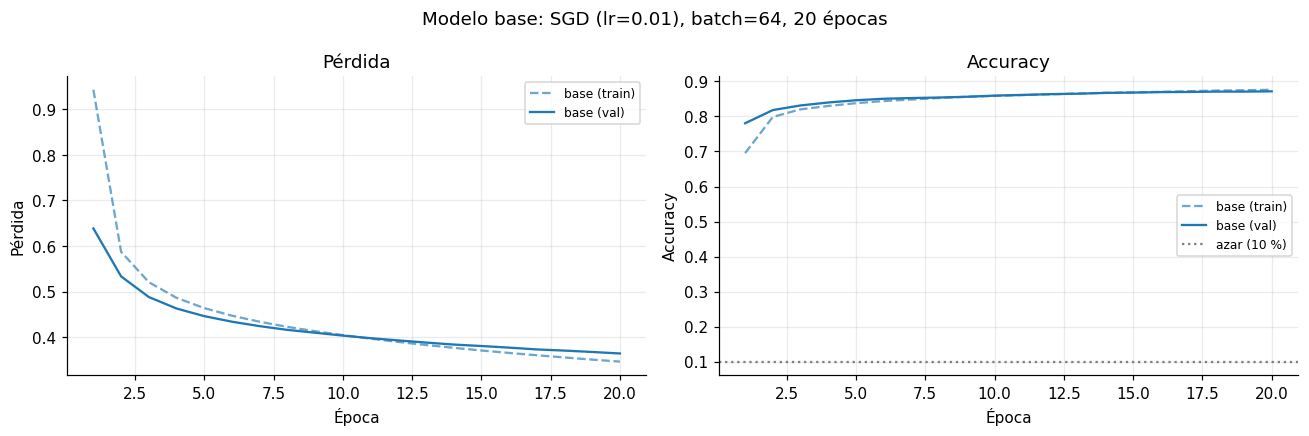

experimento,base
acc train (final),0.8763
acc val (final),0.8718
mejor acc val,0.8718
época del mejor val,20.0000
pérdida train (final),0.3463
pérdida val (final),0.3642
brecha acc (train - val),0.0045
tiempo total (s),71.6955
s / época,3.5848


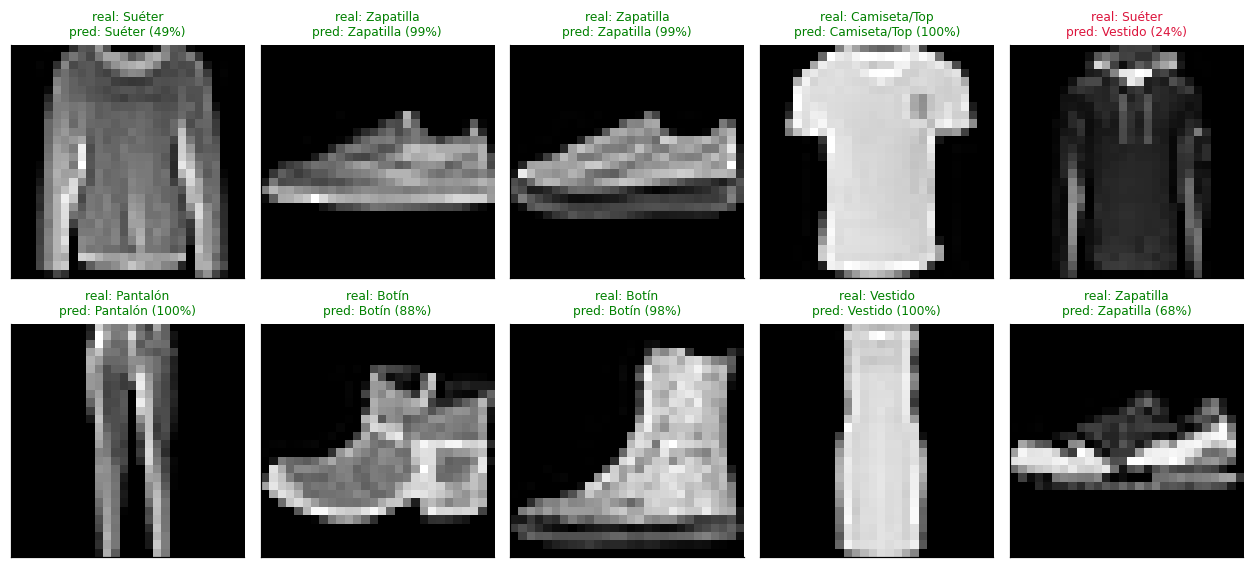

In [ ]:
# ============================================================
# 6.8 Curvas, tabla de métricas y ejemplos de predicciones
# ============================================================
graficar_curvas(["base"], "Modelo base: SGD (lr=0.01), batch=64, 20 épocas")
display(tabla_resumen(["base"]).T)
mostrar_predicciones(modelo_base, n=10)


### 📝 Interpretación del modelo base

**Referencia para todo el resto del notebook:** modelo base → **accuracy de validación = 87,18 %**, **pérdida de validación = 0,3642**, 65,5 s de entrenamiento.

**1. Verificaciones previas: superadas.**
- Para una imagen sin entrenar, las 10 salidas suman 1,000000 y están entre 0 y 1: la capa softmax entrega una distribución de probabilidad.
- **Pérdida inicial = 2,4116** frente a los 2,3026 de referencia (ln 10) y **accuracy inicial = 6,6 %** (por debajo del 10 % del azar). Es coherente con lo anticipado en 6.6: una red sin entrenar no reparte la probabilidad de forma perfectamente uniforme; en la imagen de ejemplo la clase 7 recibe 16,3 % y la clase 9 solo 3,9 %. Una pérdida de 2,41 no es una señal de error (un error se manifestaría, por ejemplo, con una pérdida de 20).
- **Memoriza 256 imágenes con 100 % de accuracy** (pérdida 0,0010): el pipeline completo (datos, etiquetas, red, entrenamiento) es capaz de aprender.

**2. Aprendizaje: la red aprende mucho en pocas épocas.**
El accuracy de entrenamiento sube de 69,5 % (época 1) a 87,6 % (época 20), y el de validación de 78,1 % a **87,2 %**, es decir, ≈ 77 puntos porcentuales sobre el azar. La pérdida baja de 0,943 a 0,346 (train) y de 0,639 a 0,364 (val).
*Observación para la defensa:* en las primeras épocas la curva de validación está **por encima** de la de entrenamiento (época 1: 78,1 % vs 69,5 %). No es un error: el accuracy de entrenamiento que reporta Keras es el **promedio durante la época**, con pesos que van mejorando, mientras que el de validación se mide **al final** de la época con los pesos ya actualizados.

**3. Convergencia: no convergió (la hipótesis de 6.4 se confirma).**
El mejor accuracy de validación ocurre en la **última época (20)** y la pérdida de validación sigue bajando en cada época. El aprendizaje se desacelera mucho, pero no se detiene: entre las épocas 1 y 5 el accuracy de validación mejora +6,6 puntos (78,07 → 84,63 %), y entre las épocas 15 y 20 solo +0,36 puntos (86,82 → 87,18 %) mientras la pérdida de validación baja de 0,3805 a 0,3642. Hay margen de mejora con **más épocas** o con una **tasa de aprendizaje mayor**; es exactamente lo que se estudia en la Sección 7 (experimentos controlados).

**4. Generalización: sin sobreajuste, con una brecha que empieza a abrirse.**
La brecha de accuracy (train − val) es de solo 0,45 puntos y la pérdida de validación nunca sube. Sin embargo, la pérdida de entrenamiento pasa por debajo de la de validación desde la época 11 y la diferencia crece: ≈ 0,00 (épocas 10–11) → 0,010 (época 15) → 0,018 (época 20). *No hay sobreajuste todavía*, pero conviene vigilarlo si se entrena más tiempo o con más capacidad. Como el accuracy de entrenamiento es un promedio durante la época, la brecha real al final de cada época es algo mayor que la reportada.

**5. Costo.**
65,5 s en total → **3,3 s por época** (≈ 4 ms por iteración; la primera época tarda más, 5 s, por la preparación del grafo de cálculo). Cada corrida de 20 épocas en los experimentos siguientes costará aproximadamente 1 minuto; con lotes más pequeños, más.

**6. Predicciones de ejemplo (10 imágenes de validación).**
Acierta 9 de 10, con confianza entre 49 % y 100 % en los aciertos. El único error es un **Suéter** (una prenda oscura con capucha) clasificado como **Vestido** con solo 24 % de probabilidad: el modelo duda. Encaja con el EDA (prendas muy oscuras, mucha variación de brillo y forma). Diez imágenes no son evidencia estadística; el análisis serio de errores se hace con la matriz de confusión en la evaluación final.


---
# 7. Experimentos controlados de entrenamiento

## 7.1 Diseño experimental

**Objetivo.** Medir cómo influye cada hiperparámetro de entrenamiento en el aprendizaje, cambiando **uno solo a la vez** y dejando todo lo demás idéntico al modelo base. Solo así una diferencia en los resultados se puede atribuir con confianza al factor modificado.

**Qué se mantiene fijo en todos los experimentos:**
mismas particiones de datos (entrenamiento 50.000 / validación 10.000), misma arquitectura 784 → 128 → 64 → 10 con ReLU, misma pérdida (entropía cruzada), mismo optimizador (SGD sin *momentum*), misma semilla (42, es decir, los **mismos pesos iniciales**) y misma métrica de comparación (accuracy y pérdida en **validación**).

| Experimento | Factor que cambia | Valores (en **negrita** = base) | Corridas nuevas |
|---|---|---|---|
| **E0** Ruido entre corridas | semilla | **42**, 43, 44 | 2 |
| **E1** Tasa de aprendizaje | $\lambda$ | 0,001 · **0,01** · 0,05 · 0,1 · 0,5 | 4 |
| **E2** Tamaño de lote | batch | 16 · 32 · **64** · 128 · 512 | 4 |
| **E3** Épocas | épocas | 5 · 10 · **20** · 40 · 60 | 1 (de 60 épocas) |
| **E4** Normalización (control) | entradas sin normalizar | sin normalizar vs. **[0, 1]** | 1 |
| **E5** Estandarización (opcional) | z-score | z-score vs. **[0, 1]** | 1 |

**Cómo se estudia E3 con una sola corrida.** La tasa de aprendizaje es constante y no hay reinicios, así que el modelo tras *k* épocas de una corrida larga es el mismo que obtendríamos entrenando solo *k* épocas con la misma semilla. Una corrida de 60 épocas permite entonces leer los resultados en las épocas 5, 10, 20, 40 y 60. Lo verificaremos comparando la época 20 de esa corrida con el modelo base.

**¿Cómo sabemos que una diferencia es real y no azar?** Dos entrenamientos con la misma configuración pero distinta semilla no dan exactamente el mismo resultado (otra inicialización y otro orden de los lotes). En **E0** medimos esa variación con el modelo base entrenado con 3 semillas. Definimos como **umbral de ruido** el rango (máximo − mínimo) del accuracy de validación final entre esas 3 corridas. En las tablas comparativas, una diferencia respecto del base solo se considera **real** si supera ese umbral; diferencias menores se consideran indistinguibles del azar.

**Hipótesis previas** (las escribimos *antes* de ver los resultados, para poder confirmarlas o refutarlas):

| # | Hipótesis |
|---|---|
| H1 | El modelo base no converge en 20 épocas (sección anterior). Con $\lambda$ = 0,05 y 0,1 alcanzará más accuracy en el mismo número de épocas; con $\lambda$ = 0,001 quedará claramente por debajo; $\lambda$ = 0,5 podría ser inestable. |
| H2 | A igual número de épocas, los lotes pequeños aprenden más rápido (más actualizaciones por época) pero cada época cuesta más tiempo; medido en **actualizaciones**, las curvas se parecen mucho más. |
| H3 | La pérdida de validación seguirá bajando más allá de la época 20; la brecha entrenamiento–validación crecerá. |
| H4 | Sin normalizar, el entrenamiento será inestable, colapsará o quedará mucho peor (justifica la decisión de normalizar tomada en el preprocesamiento). |
| H5 | La estandarización z-score dará un resultado similar al min-max (diferencia dentro del ruido). |

**Limitaciones del diseño (para la defensa):** (1) variar un factor a la vez no detecta **interacciones** (p. ej. $\lambda$ y tamaño de lote están relacionados); las combinaciones quedan como trabajo futuro. (2) Salvo el modelo base, cada configuración se entrena con **una sola semilla**. (3) Todas las decisiones se toman con validación; el test sigue intacto.

**Tiempo estimado de ejecución de esta sección:** entre 15 y 25 minutos en Colab (CPU). Las celdas **no repiten** entrenamientos ya hechos en la sesión, así que se pueden ejecutar por bloques.


In [ ]:
# ============================================================
# 7.2 Herramientas para los experimentos
# ============================================================
UMBRAL_RUIDO_PP = None     # rango de accuracy entre semillas, en puntos porcentuales (se calcula en E0)
UMBRAL_RUIDO_PERD = None   # rango de la pérdida de validación entre semillas (se calcula en E0)

def correr(nombre, forzar=False, **kwargs):
    """Entrena en silencio (si no se había hecho en esta sesión) y muestra una línea de resumen."""
    if nombre in RESULTADOS and not forzar:
        print(f"↺ {nombre}: ya estaba entrenado en esta sesión (se reutiliza)")
    else:
        entrenar(nombre, verbose=0, **kwargs)
    r = resumir(nombre)
    print(f"✔ {nombre:<16} acc val final = {r['acc val (final)']:.4f} | "
          f"pérdida val final = {r['pérdida val (final)']:.4f} | {r['tiempo total (s)']:.0f} s")

def etiquetas_de(nombres, clave, formato):
    """Texto de leyenda a partir de la configuración guardada (p. ej. 'lr=0.05')."""
    return {n: formato.format(RESULTADOS[n]["config"][clave]) for n in nombres}

def _veces(delta, umbral):
    """Cuántas veces el umbral de ruido representa la diferencia observada."""
    if umbral is not None and umbral > 0:
        return abs(delta) / umbral
    return 0.0 if delta == 0 else np.inf

def _lectura(veces):
    """Regla graduada (ver E0): <=1x ruido | 1x-2x sugerente | >2x sólida."""
    return "ruido" if veces <= 1 else ("sugerente" if veces <= 2 else "sólida")

def tabla_comparativa(nombres, ref="base", etiquetas=None):
    """Métricas clave, diferencia respecto de la referencia y lectura graduada del ruido."""
    h_ref = RESULTADOS[ref]["historia"]
    filas = []
    for n in nombres:
        r = resumir(n)
        h = RESULTADOS[n]["historia"]
        d_acc = (r["acc val (final)"] - h_ref["val_accuracy"][-1]) * 100
        d_per = r["pérdida val (final)"] - h_ref["val_loss"][-1]
        v_acc, v_per = _veces(d_acc, UMBRAL_RUIDO_PP), _veces(d_per, UMBRAL_RUIDO_PERD)
        es_ref = (n == ref)
        filas.append({
            "experimento": (etiquetas or {}).get(n, n),
            "acc val final": r["acc val (final)"],
            "mejor acc val": r["mejor acc val"],
            "época del mejor": r["época del mejor val"],
            "pérdida val final": r["pérdida val (final)"],
            "brecha acc (train-val)": r["brecha acc (train - val)"],
            "s / época": r["s / época"],
            "tiempo total (s)": r["tiempo total (s)"],
            "Δ acc vs ref (pp)": 0.0 if es_ref else d_acc,
            "× umbral acc": 0.0 if es_ref else v_acc,
            "lectura": "—" if es_ref else _lectura(v_acc),
            "Δ pérdida val": 0.0 if es_ref else d_per,
            "× umbral pérdida": 0.0 if es_ref else v_per,
            "divergió (NaN)": "sí" if np.isnan(h["loss"]).any() else "no",
        })
    return pd.DataFrame(filas).set_index("experimento").round(4)

def graficar_barrido(nombres, clave, xlabel, log_x=False, ref="base"):
    """Accuracy de validación final y tiempo por época en función del valor del hiperparámetro."""
    valores = [RESULTADOS[n]["config"][clave] for n in nombres]
    acc = [RESULTADOS[n]["historia"]["val_accuracy"][-1] for n in nombres]
    seg = [resumir(n)["s / época"] for n in nombres]
    ref_acc = RESULTADOS[ref]["historia"]["val_accuracy"][-1]
    v_ref = RESULTADOS[ref]["config"][clave]

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
    ax[0].axhspan(ref_acc - UMBRAL_RUIDO_PP / 100, ref_acc + UMBRAL_RUIDO_PP / 100,
                  color="gray", alpha=0.25, label="zona de ruido (ref ± umbral)")
    ax[0].plot(valores, acc, "o-", label="acc val final")
    ax[0].plot([v_ref], [ref_acc], "s", color="C3", ms=9, label="referencia")
    ax[0].set(xlabel=xlabel, ylabel="Accuracy de validación (final)", title="Efecto sobre el accuracy")
    ax[0].legend(fontsize=8)
    ax[1].plot(valores, seg, "o-", color="C2")
    ax[1].set(xlabel=xlabel, ylabel="Segundos por época", title="Efecto sobre el costo")
    if log_x:
        for a in ax:
            a.set_xscale("log")
    plt.tight_layout()
    plt.show()

print("Herramientas para los experimentos definidas.")


Herramientas de la Parte 3 definidas.


## 7.3 E0 — Ruido entre corridas (¿cuánto varía el resultado solo por azar?)

**Qué hacemos.** Entrenamos el modelo base con dos semillas más (43 y 44), sin cambiar nada más. La semilla afecta la **inicialización de los pesos** y el **orden de los lotes**. La variación entre las tres corridas es el "piso" de lo que podemos medir: cualquier mejora menor que esa variación no se puede distinguir del azar.

**Qué esperamos ver.** Curvas casi superpuestas y una diferencia final de pocas décimas de punto porcentual.


↺ base_s43: ya estaba entrenado en esta sesión (se reutiliza)
✔ base_s43         acc val final = 0.8682 | pérdida val final = 0.3756 | 64 s
↺ base_s44: ya estaba entrenado en esta sesión (se reutiliza)
✔ base_s44         acc val final = 0.8759 | pérdida val final = 0.3574 | 63 s


,semilla,acc val final,pérdida val final
base,42,0.8718,0.3642
base_s43,43,0.8682,0.3756
base_s44,44,0.8759,0.3574


Accuracy val: media = 0.8720 | desv. estándar = 0.0039 | rango = 0.770 puntos porcentuales
→ Umbral de ruido adoptado: 0.770 pp (solo diferencias mayores se considerarán reales)


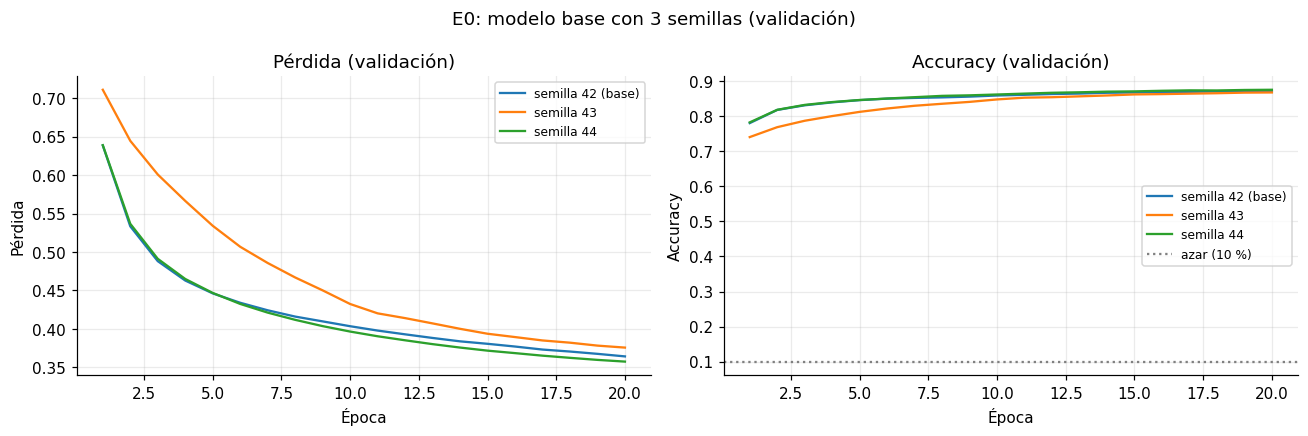

In [ ]:
# ============================================================
# 7.3 E0 — Ruido entre corridas
# ============================================================
correr("base_s43", semilla=43)
correr("base_s44", semilla=44)

sem = ["base", "base_s43", "base_s44"]
accs = np.array([RESULTADOS[n]["historia"]["val_accuracy"][-1] for n in sem])
perd = np.array([RESULTADOS[n]["historia"]["val_loss"][-1] for n in sem])

UMBRAL_RUIDO_PP = (accs.max() - accs.min()) * 100   # rango entre semillas, en puntos porcentuales
UMBRAL_RUIDO_PERD = perd.max() - perd.min()          # rango entre semillas de la pérdida de validación

display(pd.DataFrame({
    "semilla": [RESULTADOS[n]["config"]["semilla"] for n in sem],
    "acc val final": accs,
    "pérdida val final": perd,
}, index=sem).round(4))
print(f"Accuracy val: media = {accs.mean():.4f} | desv. estándar = {accs.std(ddof=1):.4f} | "
      f"rango = {UMBRAL_RUIDO_PP:.3f} puntos porcentuales")
print(f"→ Umbral de ruido adoptado: {UMBRAL_RUIDO_PP:.3f} pp "
      f"(solo diferencias mayores se considerarán reales)")

graficar_curvas(sem, "E0: modelo base con 3 semillas (validación)", solo_val=True,
                etiquetas={"base": "semilla 42 (base)", "base_s43": "semilla 43", "base_s44": "semilla 44"})


### 📝 Interpretación E0

| Semilla | Accuracy val final | Pérdida val final |
|---|---|---|
| 42 (base) | 87,18 % | 0,3642 |
| 43 | 86,82 % | 0,3756 |
| 44 | 87,59 % | 0,3574 |

- **Media = 87,20 %, desviación estándar = 0,39 pp, rango = 0,77 pp → umbral de ruido en accuracy = 0,77 pp.** La pérdida de validación varía en un rango de **0,018** (0,3574–0,3756); la usamos como segunda señal, más fina que el accuracy.
- Las semillas 42 y 44 son prácticamente indistinguibles en ambas curvas. La **semilla 43 arranca peor** (época 1: accuracy ≈ 74 % frente a ≈ 78 %; pérdida ≈ 0,71 frente a ≈ 0,64) y converge más lento, pero la brecha se reduce hacia la época 20. **La inicialización pesa sobre todo al comienzo del entrenamiento.**
- **Limitación:** con solo 3 semillas, y una de ellas algo atípica, el umbral es una estimación gruesa.

**Regla graduada que usaremos para leer todo lo que sigue:**

| Diferencia respecto de la referencia | Lectura |
|---|---|
| ≤ 1× el umbral (≤ 0,77 pp) | **indistinguible del azar** |
| entre 1× y 2× (0,77–1,54 pp) | **sugerente**, no concluyente |
| > 2× (> 1,54 pp) | **evidencia sólida** |

Exigimos además **coherencia con la pérdida** (rango de ruido = 0,018). La columna "¿supera el ruido?" de las tablas de las secciones 7.4–7.9 marca "sí" desde 1×, por lo que debe leerse con esta regla; las tablas siguientes ya incluyen la lectura graduada.


## 7.4 E1 — Tasa de aprendizaje $\lambda$

**Qué controla.** En cada iteración el descenso de gradiente actualiza $\theta \leftarrow \theta - \lambda\,\nabla_{\theta}\mathcal{L}$: $\lambda$ es el **tamaño del paso**. Según la teoría del descenso de gradiente:
- si $\lambda$ es **demasiado grande**, el algoritmo "se pasa" del mínimo: la pérdida oscila o puede diverger;
- si es **demasiado pequeña**, converge, pero necesita muchísimos pasos para llegar.

**Qué variamos.** $\lambda \in \{0{,}001;\ 0{,}01\ (\text{base});\ 0{,}05;\ 0{,}1;\ 0{,}5\}$ (escala aproximadamente logarítmica), con 20 épocas y lote 64 fijos. Para $\lambda$ = 0,5 activamos `TerminateOnNaN`: si la pérdida se vuelve `NaN` (divergencia), el entrenamiento se detiene en vez de seguir inútilmente.

**Hipótesis H1:** el base aún no converge, así que $\lambda$ = 0,05 y 0,1 mejorarán el accuracy en 20 épocas; 0,001 quedará bastante por debajo; 0,5 podría ser inestable.

**Cómo leer los resultados:** (1) *velocidad*: qué tan rápido baja la pérdida en las primeras épocas; (2) *punto final*: accuracy de validación a las 20 épocas y si supera el umbral de ruido; (3) *estabilidad*: curvas suaves o con saltos; (4) *costo*: el tiempo por época no debería cambiar con $\lambda$.


↺ lr_0.001: ya estaba entrenado en esta sesión (se reutiliza)
✔ lr_0.001         acc val final = 0.8247 | pérdida val final = 0.5200 | 61 s
↺ base: ya estaba entrenado en esta sesión (se reutiliza)
✔ base             acc val final = 0.8718 | pérdida val final = 0.3642 | 72 s
↺ lr_0.05: ya estaba entrenado en esta sesión (se reutiliza)
✔ lr_0.05          acc val final = 0.8857 | pérdida val final = 0.3147 | 62 s
↺ lr_0.1: ya estaba entrenado en esta sesión (se reutiliza)
✔ lr_0.1           acc val final = 0.8745 | pérdida val final = 0.3750 | 63 s
↺ lr_0.5: ya estaba entrenado en esta sesión (se reutiliza)
✔ lr_0.5           acc val final = 0.8701 | pérdida val final = 0.3817 | 58 s


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
lr = 0.001,0.8247,0.8247,20,0.5200,-0.0055,3.0567,61.1333,-4.71,6.1169,sólida,0.1559,8.5549,no
lr = 0.01,0.8718,0.8718,20,0.3642,0.0045,3.5848,71.6955,0.00,0.0000,—,0.0000,0.0000,no
lr = 0.05,0.8857,0.8857,20,0.3147,0.0300,3.0847,61.6948,1.39,1.8052,sugerente,-0.0494,2.7133,no
lr = 0.1,0.8745,0.8802,15,0.3750,0.0512,3.1340,62.6799,0.27,0.3506,ruido,0.0108,0.5924,no
lr = 0.5,0.8701,0.8744,17,0.3817,0.0306,2.8858,57.7169,-0.17,0.2208,ruido,0.0175,0.9616,no


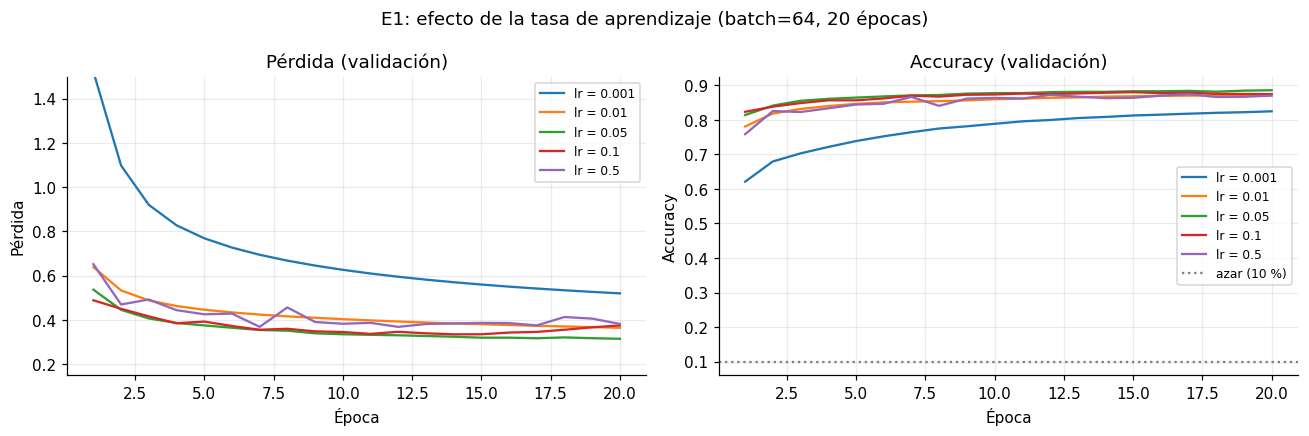

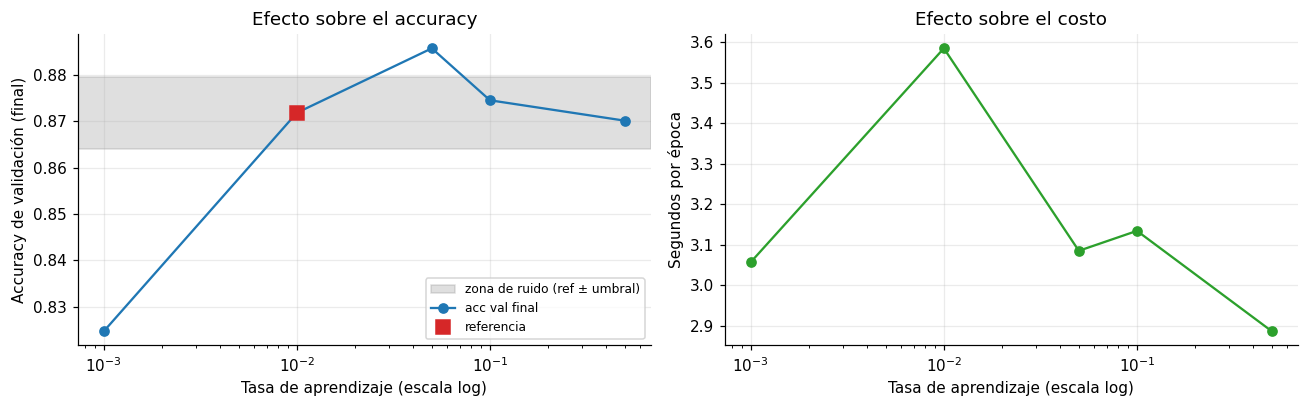

In [ ]:
# ============================================================
# 7.4 E1 — Tasa de aprendizaje
# ============================================================
LRS = [0.001, 0.01, 0.05, 0.1, 0.5]
nombres_lr = []
for lr in LRS:
    nombre = "base" if lr == LR_BASE else f"lr_{lr}"
    nombres_lr.append(nombre)
    correr(nombre, lr=lr, callbacks=[keras.callbacks.TerminateOnNaN()])

et_lr = etiquetas_de(nombres_lr, "lr", "lr = {}")
display(tabla_comparativa(nombres_lr, etiquetas=et_lr))
graficar_curvas(nombres_lr, "E1: efecto de la tasa de aprendizaje (batch=64, 20 épocas)",
                solo_val=True, etiquetas=et_lr, ylim_perdida=(0.15, 1.5))
graficar_barrido(nombres_lr, "lr", "Tasa de aprendizaje (escala log)", log_x=True)


### 📝 Interpretación E1 — Tasa de aprendizaje

| $\lambda$ | Acc. val final | Δ vs base | × umbral | Lectura | Pérdida val final | Δ pérdida (× rango 0,018) |
|---|---|---|---|---|---|---|
| 0,001 | 82,47 % | −4,71 pp | 6,1× | **sólida (peor)** | 0,5200 | +0,156 (8,6×) |
| **0,01 (base)** | 87,18 % | — | — | — | 0,3642 | — |
| **0,05** | **88,57 %** | +1,39 pp | 1,8× | sugerente | **0,3147** | −0,050 (2,7×) |
| 0,1 | 87,45 % (máx. 88,02 % en época 15) | +0,27 pp | 0,4× | ruido | 0,3750 | +0,011 (0,6×) |
| 0,5 | 87,01 % (máx. 87,44 % en época 17) | −0,17 pp | 0,2× | ruido | 0,3817 | +0,018 (1,0×) |

**Qué muestran las curvas y las tablas:**
- **$\lambda$ = 0,001 (demasiado pequeña):** avanza muy lento; el accuracy de validación parte en ≈ 62 % en la época 1 y llega a 82,5 % en la 20, con la curva **todavía subiendo**. Es el caso típico de una tasa de aprendizaje demasiado conservadora. Diferencia sólida y coherente con la pérdida.
- **$\lambda$ = 0,05 (la mejor):** aprende rápido y con curva suave; alcanza la menor pérdida de validación de todos los experimentos de 20 épocas (0,3147). Con la regla graduada, el accuracy es **sugerente** (1,8× el umbral); la **pérdida corrobora** (2,7× su rango de ruido), por eso la consideramos una mejora real, aunque moderada.
- **$\lambda$ = 0,1:** aprende rápido al inicio, pero su pérdida de validación toca fondo alrededor de las épocas 9–12 (≈ 0,34) y luego **sube hasta 0,3750**; su mejor accuracy (88,02 %, época 15) es mayor que el final, y tiene la **mayor brecha entrenamiento–validación (5,1 pp)**. Empieza a sobreajustar u oscilar antes que las demás. Su resultado final es indistinguible del base.
- **$\lambda$ = 0,5 (demasiado grande):** **no diverge** (sin `NaN`), pero la curva es **errática** (saltos visibles alrededor de las épocas 8 y 18), el comportamiento errático típico de una tasa de aprendizaje demasiado alta. No mejora al base.
- **Costo:** 3,15–3,26 s por época en todos los casos. La tasa de aprendizaje **no cambia el tiempo de cómputo** (la variación de ≈ 3 % es ruido de medición).

**Veredicto sobre H1:** *parcialmente confirmada.* Se cumple que 0,001 queda muy por debajo, que 0,05 mejora y que 0,5 es inestable (sin llegar a divergir). **No** se cumple que 0,1 mejore el resultado a las 20 épocas: aprende más rápido, pero su curva se deteriora antes.

**Decisión provisional:** $\lambda$ = 0,05. La rejilla es gruesa; el óptimo probablemente esté entre 0,03 y 0,1, pero no lo exploramos.


## 7.5 E2 — Tamaño de lote (*batch size*)

**Qué controla.** Cuántos ejemplos se usan para estimar el gradiente en cada actualización (el lote debe elegirse al azar en cada iteración).
- **Lote pequeño:** estimación del gradiente *ruidosa*, pero **muchas actualizaciones por época**.
- **Lote grande:** estimación *más precisa*, pero **pocas actualizaciones por época**.

| Lote | Iteraciones por época ($\lceil 50.000/\text{lote}\rceil$) |
|---|---|
| 16 | 3.125 |
| 32 | 1.563 |
| **64 (base)** | **782** |
| 128 | 391 |
| 512 | 98 |

**Ojo con la interpretación.** A igual número de **épocas**, cambiar el lote cambia a la vez (a) el ruido del gradiente y (b) la **cantidad de actualizaciones** de $\theta$. Para separar ambos efectos graficamos las curvas también contra las **actualizaciones acumuladas**.

**Hipótesis H2:** por época, los lotes pequeños aprenden más rápido pero cada época tarda más; contra actualizaciones, las curvas se parecen bastante más entre sí. Con $\lambda$ constante, un lote grande necesita más épocas para llegar al mismo punto.

**Cuidado con el tiempo:** el lote 16 es el más lento (≈ 4 veces el base, del orden de 4 minutos).


↺ batch_16: ya estaba entrenado en esta sesión (se reutiliza)
✔ batch_16         acc val final = 0.8875 | pérdida val final = 0.3183 | 166 s
↺ batch_32: ya estaba entrenado en esta sesión (se reutiliza)
✔ batch_32         acc val final = 0.8818 | pérdida val final = 0.3307 | 101 s
↺ base: ya estaba entrenado en esta sesión (se reutiliza)
✔ base             acc val final = 0.8718 | pérdida val final = 0.3642 | 72 s
↺ batch_128: ya estaba entrenado en esta sesión (se reutiliza)
✔ batch_128        acc val final = 0.8654 | pérdida val final = 0.3872 | 43 s
↺ batch_512: ya estaba entrenado en esta sesión (se reutiliza)
✔ batch_512        acc val final = 0.8300 | pérdida val final = 0.4936 | 25 s


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
lote = 16,0.8875,0.8880,19,0.3183,0.0228,8.3238,166.4766,1.57,2.0390,sólida,-0.0459,2.5194,no
lote = 32,0.8818,0.8818,20,0.3307,0.0114,5.0747,101.4936,1.00,1.2987,sugerente,-0.0335,1.8384,no
lote = 64,0.8718,0.8718,20,0.3642,0.0045,3.5848,71.6955,0.00,0.0000,—,0.0000,0.0000,no
lote = 128,0.8654,0.8654,20,0.3872,-0.0028,2.1738,43.4763,-0.64,0.8312,ruido,0.0231,1.2667,no
lote = 512,0.8300,0.8300,20,0.4936,-0.0038,1.2566,25.1312,-4.18,5.4286,sólida,0.1295,7.1060,no


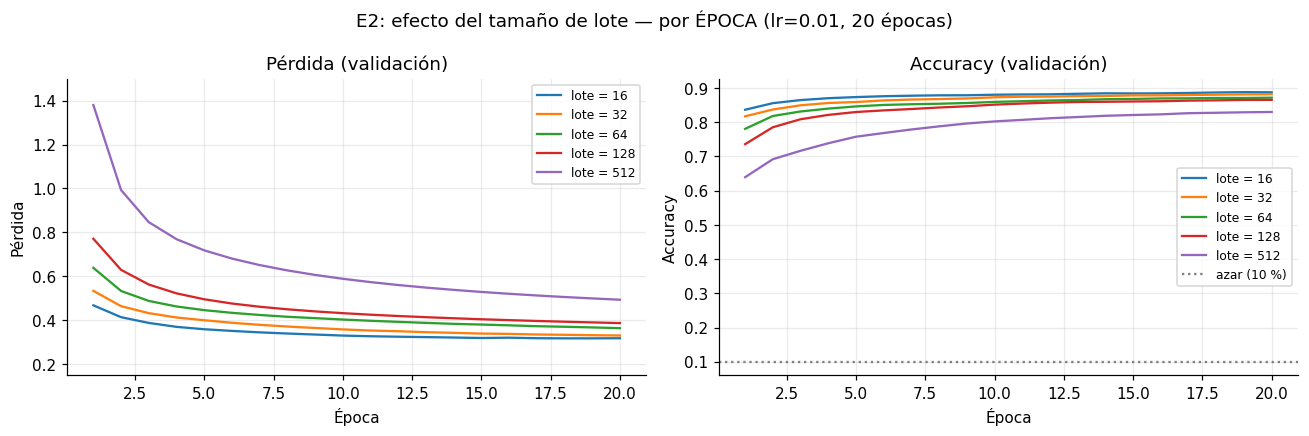

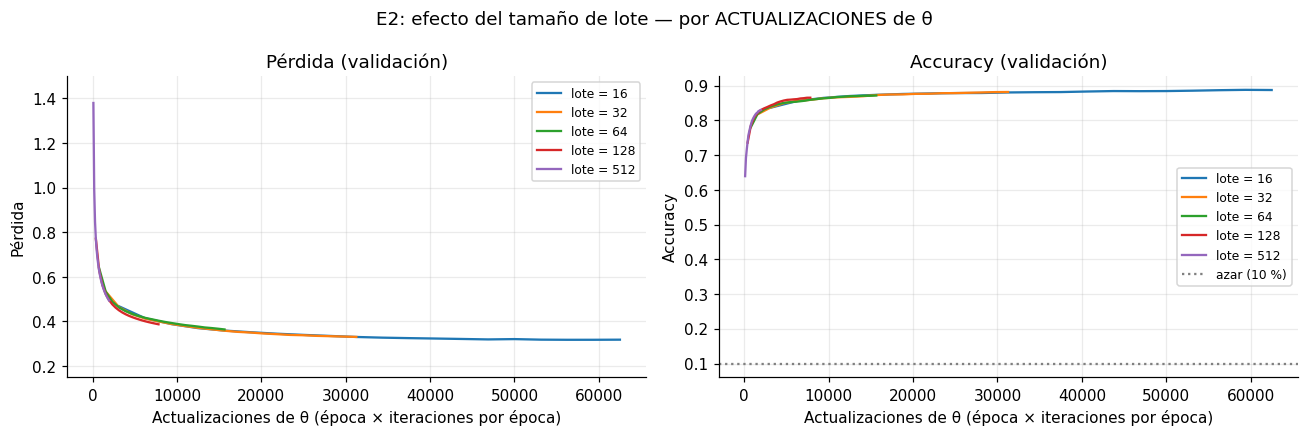

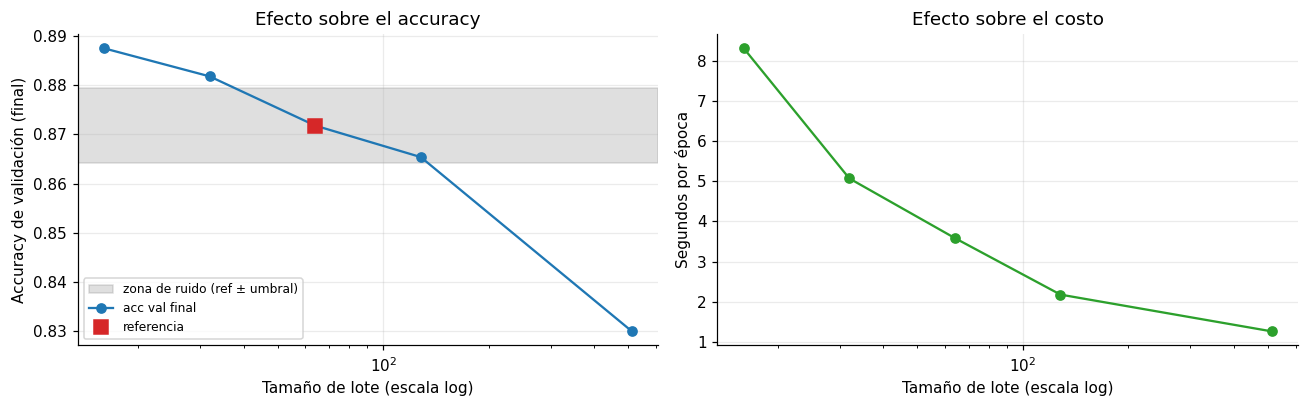

In [ ]:
# ============================================================
# 7.5 E2 — Tamaño de lote
# ============================================================
LOTES = [16, 32, 64, 128, 512]
nombres_batch = []
for b in LOTES:
    nombre = "base" if b == BATCH_BASE else f"batch_{b}"
    nombres_batch.append(nombre)
    correr(nombre, batch_size=b)

et_b = etiquetas_de(nombres_batch, "batch_size", "lote = {}")
display(tabla_comparativa(nombres_batch, etiquetas=et_b))
graficar_curvas(nombres_batch, "E2: efecto del tamaño de lote — por ÉPOCA (lr=0.01, 20 épocas)",
                solo_val=True, etiquetas=et_b, ylim_perdida=(0.15, 1.5))
graficar_curvas(nombres_batch, "E2: efecto del tamaño de lote — por ACTUALIZACIONES de θ",
                solo_val=True, etiquetas=et_b, eje="actualizaciones", ylim_perdida=(0.15, 1.5))
graficar_barrido(nombres_batch, "batch_size", "Tamaño de lote (escala log)", log_x=True)


### 📝 Interpretación E2 — Tamaño de lote

| Lote | Actualizaciones totales | Acc. val final | Δ vs base | × umbral | Lectura | Pérdida val | s / época | Tiempo total |
|---|---|---|---|---|---|---|---|---|
| 16 | 62.500 | **88,75 %** | +1,57 pp | 2,0× | sólida (en el límite) | 0,3183 | 8,97 | 179 s |
| 32 | 31.260 | 88,18 % | +1,00 pp | 1,3× | sugerente | 0,3307 | 5,24 | 105 s |
| **64 (base)** | 15.640 | 87,18 % | — | — | — | 0,3642 | 3,15 | 63 s |
| 128 | 7.820 | 86,54 % | −0,64 pp | 0,8× | ruido | 0,3872 | 2,14 | 43 s |
| 512 | 1.960 | 83,00 % | −4,18 pp | 5,4× | **sólida (peor)** | 0,4936 | 1,29 | 26 s |

**Qué muestran los gráficos:**
- **Por época:** a igual número de épocas, el accuracy **baja de forma monótona al agrandar el lote**, y el tiempo por época baja también (8,97 s → 1,29 s). Es el compromiso esperado.
- **Por actualizaciones de $\theta$:** las cinco curvas casi se **superponen**. El lote 16 hace 4 veces más actualizaciones que el 64 y el 512 hace 8 veces menos, y el accuracy sigue lo que dicta el **número de actualizaciones**, no el tamaño del lote en sí. *Ejemplo:* con 7.820 actualizaciones, el lote 64 (época 10) tenía 85,95 % y pérdida 0,4034, y el lote 128 (época 20) tiene 86,54 % y 0,3872: una ligera ventaja por actualización del lote mayor (gradiente menos ruidoso), pero de magnitud comparable al ruido.
- **Por qué el lote 512 "pierde":** en el presupuesto de 20 épocas recibió solo 1.960 actualizaciones (8 veces menos que el base); está **sin entrenar**, no es que sea peor por sí mismo.

**Veredicto sobre H2:** *confirmada.* Por época los lotes pequeños aprenden más rápido y cuestan más tiempo; medidas en actualizaciones, las curvas se parecen mucho.

**Eficiencia:** el lote 16 ganó +1,57 pp a costa de **2,8 veces el tiempo** (179 s frente a 63 s). Con $\lambda$ = 0,05 (E1) se ganó +1,39 pp **sin costo adicional**. Para "dar más actualizaciones efectivas" es más barato subir $\lambda$ que achicar el lote.

**Decisión provisional:** mantener lote 64. La interacción $\lambda$ × lote (con lote grande suele compensarse subiendo $\lambda$; es una regla práctica, no una garantía) queda como trabajo futuro.


## 7.6 E3 — Número de épocas

**Qué controla.** Cuántas pasadas completas por los datos de entrenamiento se dan. Pocas épocas → el modelo queda **sin terminar de aprender** (*underfitting*); demasiadas → puede empezar a **memorizar** el entrenamiento (*overfitting*): la pérdida de entrenamiento sigue bajando pero la de validación se estanca o **sube**. Existe un *criterio de detención* justamente para decidir cuándo parar (*early stopping*), que se trabaja más adelante (Sección 9).

**Cómo lo estudiamos.** Una sola corrida de **60 épocas** con la configuración base (ver 7.1). Leemos los resultados en las épocas 5, 10, 20, 40 y 60. Además comprobamos que la época 20 de esta corrida reproduce al modelo base, lo que valida el argumento y de paso mide la **reproducibilidad** de nuestro entorno.

**Hipótesis H3:** la pérdida de validación seguirá bajando más allá de la época 20 y la brecha entrenamiento–validación crecerá.

**Qué buscar:** la **época del mínimo de pérdida de validación** (si la pérdida sube después, ahí empieza el sobreajuste) y cuánto gana el accuracy entre cada par de cortes.


↺ epocas_60: ya estaba entrenado en esta sesión (se reutiliza)
✔ epocas_60        acc val final = 0.8874 | pérdida val final = 0.3166 | 182 s
Época 20 de la corrida larga vs modelo base -> diferencia en acc val = 0.0000 pp
✔ Reproduce al base


,acc train,acc val,pérdida train,pérdida val,brecha pérdida (val - train),Δ acc val vs corte anterior (pp)
época,,,,,,
5,0.8380,0.8463,0.4638,0.4461,-0.0177,NaN
10,0.8587,0.8595,0.4045,0.4034,-0.0011,1.32
20,0.8763,0.8718,0.3463,0.3642,0.0178,1.23
40,0.8972,0.8816,0.2837,0.3300,0.0463,0.98
60,0.9132,0.8874,0.2421,0.3166,0.0744,0.58


Época con la MENOR pérdida de validación: 60 (pérdida = 0.3166)
Época con el MAYOR accuracy de validación: 56 (acc = 0.8878)


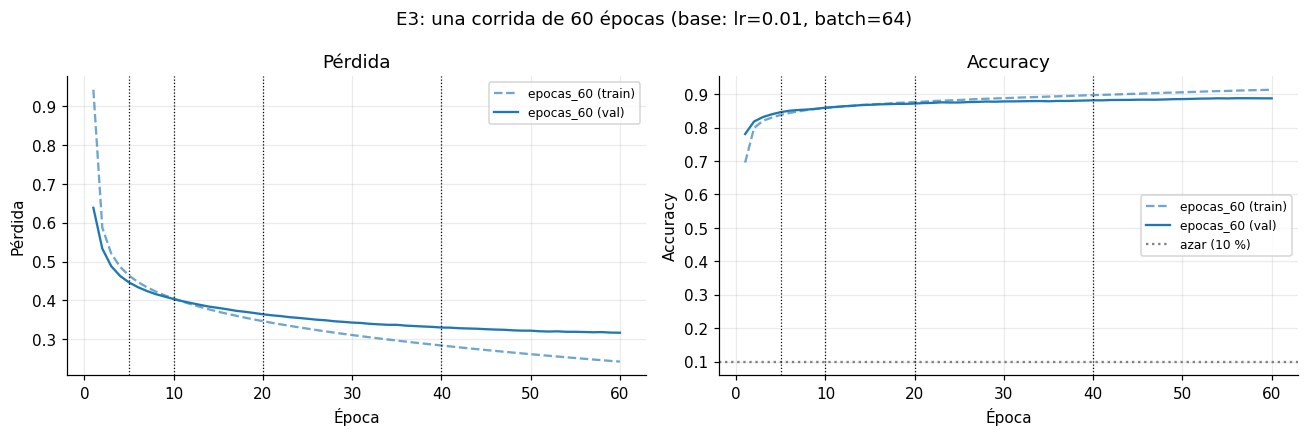

In [ ]:
# ============================================================
# 7.6 E3 — Número de épocas (una corrida de 60 épocas)
# ============================================================
correr("epocas_60", epocas=60)

h60 = RESULTADOS["epocas_60"]["historia"]
hb = RESULTADOS["base"]["historia"]

# --- Reproducibilidad: la época 20 de la corrida larga debe reproducir al base ---
dif = abs(h60["val_accuracy"][EPOCAS_BASE - 1] - hb["val_accuracy"][-1]) * 100
print(f"Época {EPOCAS_BASE} de la corrida larga vs modelo base -> diferencia en acc val = {dif:.4f} pp")
print("✔ Reproduce al base" if dif < 0.05 else "⚠ Diferencia relevante: revisar determinismo del entorno")

# --- Resultados en las épocas de corte ---
cortes = [e for e in (5, 10, 20, 40, 60) if e <= len(h60["loss"])]
df_ep = pd.DataFrame({
    "época": cortes,
    "acc train": [h60["accuracy"][e - 1] for e in cortes],
    "acc val": [h60["val_accuracy"][e - 1] for e in cortes],
    "pérdida train": [h60["loss"][e - 1] for e in cortes],
    "pérdida val": [h60["val_loss"][e - 1] for e in cortes],
}).set_index("época")
df_ep["brecha pérdida (val - train)"] = df_ep["pérdida val"] - df_ep["pérdida train"]
df_ep["Δ acc val vs corte anterior (pp)"] = df_ep["acc val"].diff() * 100
display(df_ep.round(4))

e_min = int(np.argmin(h60["val_loss"])) + 1
print(f"Época con la MENOR pérdida de validación: {e_min} (pérdida = {min(h60['val_loss']):.4f})")
print(f"Época con el MAYOR accuracy de validación: {int(np.argmax(h60['val_accuracy'])) + 1} "
      f"(acc = {max(h60['val_accuracy']):.4f})")

graficar_curvas(["epocas_60"], "E3: una corrida de 60 épocas (base: lr=0.01, batch=64)",
                marcas_epoca=[c for c in cortes if c < len(h60["loss"])])


### 📝 Interpretación E3 — Número de épocas

**Reproducibilidad:** la época 20 de la corrida de 60 épocas reproduce al modelo base con una diferencia de **0,0000 pp**. Esto valida el argumento de 7.1 (una corrida larga contiene a las cortas) y muestra que, en este entorno, la semilla fija da resultados exactos: las diferencias de E0 se deben realmente a la semilla y no a indeterminismo.

| Época | Acc. train | Acc. val | Pérdida train | Pérdida val | Brecha de pérdida (val − train) | Ganancia acc. val desde el corte anterior | Ganancia por época |
|---|---|---|---|---|---|---|---|
| 5 | 83,80 % | 84,63 % | 0,4638 | 0,4461 | −0,018 | — | — |
| 10 | 85,87 % | 85,95 % | 0,4045 | 0,4034 | −0,001 | +1,32 pp | 0,26 pp |
| 20 | 87,63 % | 87,18 % | 0,3463 | 0,3642 | +0,018 | +1,23 pp | 0,12 pp |
| 40 | 89,72 % | 88,16 % | 0,2837 | 0,3300 | +0,046 | +0,98 pp | 0,05 pp |
| 60 | 91,32 % | 88,74 % | 0,2421 | 0,3166 | +0,074 | +0,58 pp | 0,03 pp |

- **Rendimientos decrecientes:** cada época adicional aporta cada vez menos (0,26 → 0,12 → 0,05 → 0,03 pp por época). De 20 a 60 épocas se gana **+1,56 pp** (sólido: 2,0× el umbral) pero con **3 veces el tiempo** (194 s frente a 63 s).
- **La pérdida de validación sigue bajando hasta la época 60** (mínimo en la 60: 0,3166) y el mejor accuracy de validación (88,78 %) ocurre en la época 56, prácticamente igual al de la 60. **No hay sobreajuste en sentido estricto** (la pérdida de validación no sube).
- **Sin embargo, la brecha crece de forma sostenida:** la pérdida de validación pasa de estar *por debajo* de la de entrenamiento (−0,018 en la época 5) a estar **0,074 por encima** en la época 60; en accuracy, 2,6 pp de brecha (91,3 % frente a 88,7 %). La red mejora en entrenamiento más rápido que en validación: **memoriza progresivamente**. Este es el escenario donde la regularización (Sección 9) debería ayudar.

**Veredicto sobre H3:** *confirmada.* La pérdida de validación sigue bajando más allá de la época 20 y la brecha crece.

**Decisión provisional:** para las comparaciones de las secciones siguientes se mantienen **20 épocas** (costo controlado y comparaciones equitativas). En la configuración final se usarán más épocas con *early stopping* (criterio de detención) junto con regularización.


## 7.7 E4 — Control: entrenar sin normalizar las entradas

**Por qué este experimento.** En el preprocesamiento decidimos dividir los píxeles por 255, y en el EDA vimos que sin normalizar las entradas llegan hasta 255 con una desviación estándar ≈ 90. Este experimento **pone a prueba esa decisión con datos**: entrenamos exactamente el mismo modelo con los píxeles originales en [0, 255].

**Qué medimos.**
1. La **pérdida inicial** de la red sin entrenar con entradas sin normalizar, comparada con la normalizada (2,41; ver Sección 6). Con entradas enormes se espera una pérdida inicial mucho mayor: la softmax se satura y asigna probabilidades ≈ 0 o ≈ 1.
2. La curva de entrenamiento completa (activamos `TerminateOnNaN` por si el entrenamiento diverge).

**Hipótesis H4:** sin normalizar, el entrenamiento será inestable, colapsará o quedará mucho peor que con [0, 1].


Pérdida inicial con entradas normalizadas [0,1] : 2.4116  (acc 6.6%)
Pérdida inicial con entradas SIN normalizar     : 121.8952  (acc 6.6%)
↺ sin_normalizar: ya estaba entrenado en esta sesión (se reutiliza)
✔ sin_normalizar   acc val final = 0.1000 | pérdida val final = 2.3988 | 60 s


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
"normalizado [0,1] (base)",0.8718,0.8718,20,0.3642,0.0045,3.5848,71.6955,0.00,0.0000,—,0.0000,0.0000,no
"sin normalizar [0,255]",0.1000,0.1000,1,2.3988,-0.0030,2.9807,59.6131,-77.18,100.2342,sólida,2.0347,111.6673,no


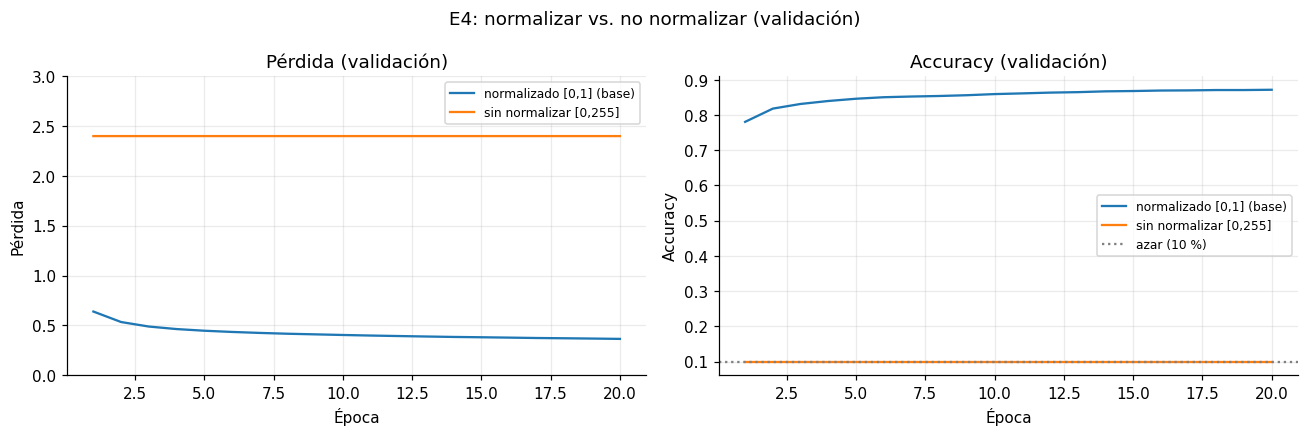

In [ ]:
# ============================================================
# 7.7 E4 — Sin normalizar (píxeles originales 0-255)
# ============================================================
X_raw_train = x_train_img.reshape(len(x_train_img), NUM_ENTRADAS).astype("float32")   # 0..255 sin dividir
X_raw_val = x_val_img.reshape(len(x_val_img), NUM_ENTRADAS).astype("float32")

# --- Pérdida inicial (red SIN entrenar) con ambas versiones de los datos ---
reiniciar_semillas()
m_ini = compilar_modelo(construir_modelo(nombre="ini_sin_normalizar"))
loss_raw, acc_raw = m_ini.evaluate(X_raw_val, Y_val, verbose=0)
loss_norm, acc_norm = m_ini.evaluate(X_val, Y_val, verbose=0)
print(f"Pérdida inicial con entradas normalizadas [0,1] : {loss_norm:.4f}  (acc {acc_norm:.1%})")
print(f"Pérdida inicial con entradas SIN normalizar     : {loss_raw:.4f}  (acc {acc_raw:.1%})")

# --- Entrenamiento con la configuración base, solo cambian los datos ---
correr("sin_normalizar", datos=(X_raw_train, Y_train, X_raw_val, Y_val),
       callbacks=[keras.callbacks.TerminateOnNaN()])

nombres_norm = ["base", "sin_normalizar"]
et_norm = {"base": "normalizado [0,1] (base)", "sin_normalizar": "sin normalizar [0,255]"}
display(tabla_comparativa(nombres_norm, etiquetas=et_norm))
graficar_curvas(nombres_norm, "E4: normalizar vs. no normalizar (validación)", solo_val=True,
                etiquetas=et_norm, ylim_perdida=(0, 3))


### 📝 Interpretación E4 — Sin normalizar

| | Normalizado [0,1] (base) | Sin normalizar [0,255] |
|---|---|---|
| Pérdida inicial (red sin entrenar) | 2,41 | **121,90** |
| Accuracy val final | 87,18 % | **10,00 %** (= azar) |
| Pérdida val final | 0,3642 | 2,3988 |
| Mejor accuracy val / época | 87,18 % / 20 | 10,00 % / 1 |
| ¿NaN? | no | **no** |

- **Pérdida inicial 50 veces mayor:** con entradas de hasta 255 (desviación ≈ 90), los valores que llegan a la softmax son enormes y la red asigna probabilidades casi 0 o casi 1 a clases equivocadas. Se confirma lo previsto en el EDA (hallazgo 3).
- **El entrenamiento colapsa, no diverge.** No aparece `NaN`; en cambio la pérdida de validación queda **plana en ≈ 2,40 y el accuracy en exactamente 10,00 % durante las 20 épocas**. Una red que acierta exactamente el 10 % de un conjunto balanceado está devolviendo **siempre la misma clase**, y una pérdida ≈ 2,40 (≥ ln 10 = 2,3026) es la que corresponde a una salida constante que no depende de la imagen.
- **Explicación más probable (consistente con la evidencia, aunque no inspeccionamos las activaciones):** los primeros pasos, con gradientes enormes, empujan los pesos a valores en los que las neuronas ReLU quedan inactivas (pre-activación negativa para todas las imágenes) y la red deja de responder a la entrada. Sin señal de la entrada no hay gradiente útil y el entrenamiento no se recupera.
- Diferencia respecto del base: **−77,2 pp**, unas 100 veces el umbral de ruido.

**Veredicto sobre H4:** *confirmada* (colapso). Este experimento **respalda con datos la decisión tomada en el preprocesamiento**: normalizar es indispensable en este entrenamiento.


## 7.8 E5 (opcional) — Estandarización z-score frente a min-max

**Motivación.** Tras el escalado a [0, 1] la media de los píxeles es ≈ 0,29: las entradas son todas positivas y no están centradas en 0. La **estandarización** $x' = (x - \mu)/\sigma$ las centra y les da desviación 1. Usamos **una sola media $\mu$ y una sola desviación $\sigma$ globales**, calculadas **solo con `X_train`** (nunca con validación ni test, para evitar fuga de información), y las aplicamos a validación. No se usa una media por píxel porque los píxeles de los bordes valen siempre 0 y tienen desviación 0 (división por cero).

**Hipótesis H5:** el resultado final será similar al de min-max (diferencia dentro del ruido). Si es así, mantenemos min-max por simplicidad.


μ = 0.2863 | σ = 0.3532  (calculados con X_train)
Tras estandarizar -> media de train = 0.0000, desv. = 1.0000
↺ zscore: ya estaba entrenado en esta sesión (se reutiliza)
✔ zscore           acc val final = 0.8872 | pérdida val final = 0.3151 | 62 s


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
"min-max [0,1] (base)",0.8718,0.8718,20,0.3642,0.0045,3.5848,71.6955,0.00,0.0,—,0.0000,0.0000,no
z-score,0.8872,0.8872,20,0.3151,0.0197,3.0826,61.6519,1.54,2.0,sólida,-0.0491,2.6929,no


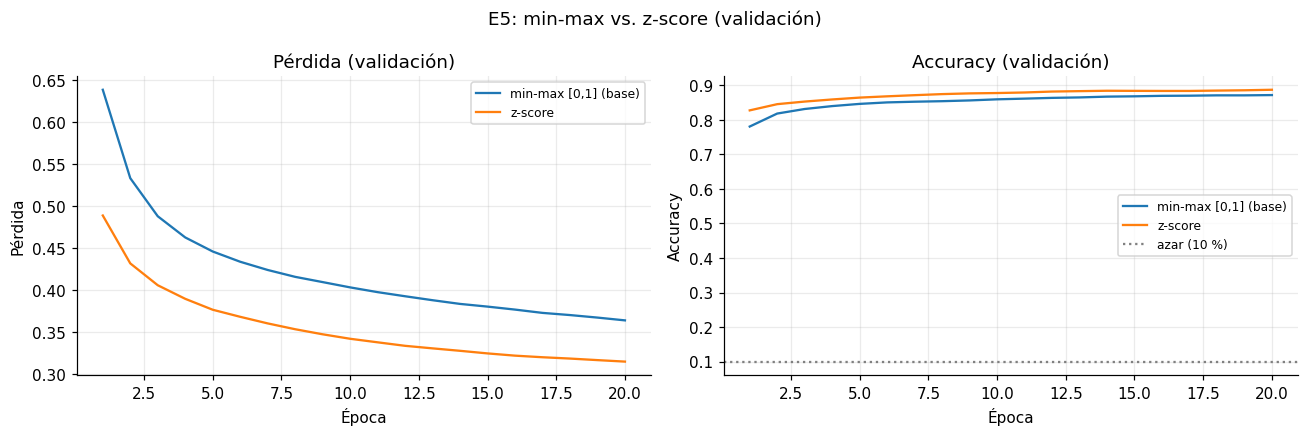

In [ ]:
# ============================================================
# 7.8 E5 (opcional) — Estandarización z-score
# ============================================================
mu, sigma = X_train.mean(), X_train.std()          # SOLO con entrenamiento
print(f"μ = {mu:.4f} | σ = {sigma:.4f}  (calculados con X_train)")

Xz_train = ((X_train - mu) / sigma).astype("float32")
Xz_val = ((X_val - mu) / sigma).astype("float32")
print(f"Tras estandarizar -> media de train = {Xz_train.mean():.4f}, desv. = {Xz_train.std():.4f}")

correr("zscore", datos=(Xz_train, Y_train, Xz_val, Y_val))

nombres_z = ["base", "zscore"]
et_z = {"base": "min-max [0,1] (base)", "zscore": "z-score"}
display(tabla_comparativa(nombres_z, etiquetas=et_z))
graficar_curvas(nombres_z, "E5: min-max vs. z-score (validación)", solo_val=True, etiquetas=et_z)


### 📝 Interpretación E5 — Estandarización z-score

μ = 0,2863 y σ = 0,3532, calculados solo con `X_train` (coinciden con lo visto en el EDA: media ≈ 0,286 y desviación ≈ 0,353). Tras estandarizar, `X_train` tiene media 0 y desviación 1.

| | min-max [0,1] (base) | z-score |
|---|---|---|
| Acc. val final | 87,18 % | **88,72 %** |
| Δ vs base | — | **+1,54 pp (≈ 2,0× el umbral: en el límite de "sólida")** |
| Pérdida val final | 0,3642 | **0,3151** (−0,049; 2,7× el rango de ruido de la pérdida) |
| Brecha acc (train − val) | 0,45 pp | 1,97 pp |
| Época 1 (pérdida / acc val) | ≈ 0,64 / ≈ 78 % | ≈ 0,49 / ≈ 83 % |

- **Aprende más rápido desde la primera época y la ventaja se mantiene** durante las 20 (las curvas nunca se cruzan). Costo: nulo (el tiempo por época es el mismo).
- La evidencia en accuracy está justo en el límite de la regla (2,0×), pero es **consistente con la pérdida** (2,7×) y con la forma de las curvas en todas las épocas; la consideramos una mejora real.
- **Veredicto sobre H5:** *refutada.* Esperábamos un resultado similar a min-max (dentro del ruido) y z-score resultó mejor.
- **Por qué podría ocurrir (hipótesis, no probada):** z-score hace dos cosas a la vez: (a) **centra** las entradas en 0 (con min-max eran todas positivas, media ≈ 0,29) y (b) las **escala** ≈ 2,8 veces (1/0,353). El escalado aumenta las señales y los gradientes de la primera capa, lo que puede equivaler a una tasa de aprendizaje efectiva mayor en esa capa. Nuestros experimentos **no separan ambos efectos**, y es notable que z-score (88,72 %) y $\lambda$ = 0,05 (88,57 %) den resultados casi iguales: pueden estar actuando por un mecanismo parecido. Por eso hay que probar la **combinación** antes de asumir que los efectos se suman (ver 8.1).

**Decisión:** adoptar la estandarización z-score como preprocesamiento de las entradas **a partir de la Sección 8**.


## 7.9 Resumen de los experimentos

Tabla única con todos los experimentos, ordenada por accuracy de validación final, y gráfico comparativo con la **zona de ruido** del modelo base. Recuerda que `epocas_60` se evalúa a las 60 épocas, por eso no es comparable "uno a uno" con los demás (20 épocas); su lectura está en 7.6.


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
batch_16,0.8875,0.8880,19,0.3183,0.0228,8.3238,166.4766,1.57,2.0390,sólida,-0.0459,2.5194,no
epocas_60,0.8874,0.8878,56,0.3166,0.0258,3.0282,181.6946,1.56,2.0260,sólida,-0.0476,2.6127,no
zscore,0.8872,0.8872,20,0.3151,0.0197,3.0826,61.6519,1.54,2.0000,sólida,-0.0491,2.6929,no
lr_0.05,0.8857,0.8857,20,0.3147,0.0300,3.0847,61.6948,1.39,1.8052,sugerente,-0.0494,2.7133,no
batch_32,0.8818,0.8818,20,0.3307,0.0114,5.0747,101.4936,1.00,1.2987,sugerente,-0.0335,1.8384,no
base_s44,0.8759,0.8759,20,0.3574,0.0003,3.1676,63.3511,0.41,0.5325,ruido,-0.0068,0.3716,no
lr_0.1,0.8745,0.8802,15,0.3750,0.0512,3.1340,62.6799,0.27,0.3506,ruido,0.0108,0.5924,no
base,0.8718,0.8718,20,0.3642,0.0045,3.5848,71.6955,0.00,0.0000,—,0.0000,0.0000,no
lr_0.5,0.8701,0.8744,17,0.3817,0.0306,2.8858,57.7169,-0.17,0.2208,ruido,0.0175,0.9616,no


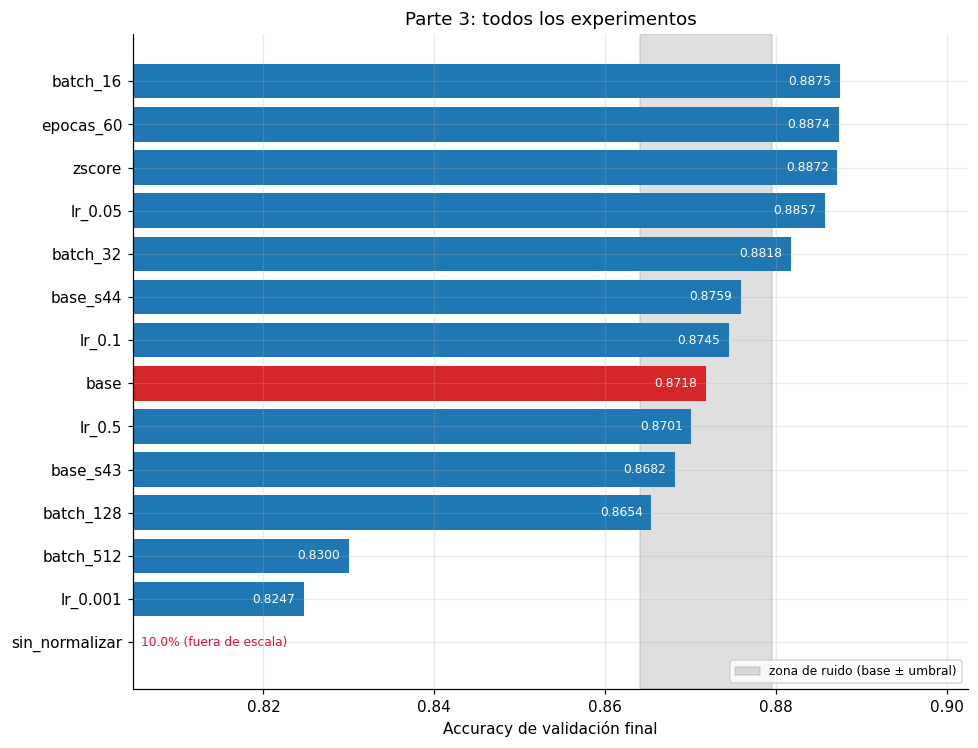

In [ ]:
# ============================================================
# 7.9 Resumen de los experimentos
# ============================================================
todos = ["base", "base_s43", "base_s44"] \
      + [n for n in nombres_lr if n != "base"] \
      + [n for n in nombres_batch if n != "base"] \
      + ["epocas_60", "sin_normalizar", "zscore"]
todos = [n for n in todos if n in RESULTADOS]

tabla_total = tabla_comparativa(todos).sort_values("acc val final", ascending=False)
display(tabla_total)

# --- Gráfico: accuracy de validación final por experimento ---
orden = tabla_total.index.tolist()[::-1]
valores = tabla_total.loc[orden, "acc val final"].values
ref_acc = RESULTADOS["base"]["historia"]["val_accuracy"][-1]

# Escala del eje: se enfoca en los resultados "razonables" (> 50 %) para que las diferencias
# pequeñas sean visibles; lo que quede por debajo se anota como "fuera de escala".
candidatos = valores[valores > 0.5]
xmin = candidatos.min() - 0.02 if len(candidatos) else 0.0
xmax = min(1.0, valores.max() + 0.015)

fig, ax = plt.subplots(figsize=(9, 0.4 * len(orden) + 1.3))
ax.axvspan(ref_acc - UMBRAL_RUIDO_PP / 100, ref_acc + UMBRAL_RUIDO_PP / 100,
           color="gray", alpha=0.25, label="zona de ruido (base ± umbral)")
ax.barh(orden, valores, color=["C3" if n == "base" else "C0" for n in orden])
for y_pos, v in enumerate(valores):
    if v < xmin:
        ax.text(xmin + 0.001, y_pos, f"{v:.1%} (fuera de escala)", va="center", fontsize=8, color="crimson")
    else:
        ax.text(v - 0.001, y_pos, f"{v:.4f}", va="center", ha="right", fontsize=8, color="white")
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Accuracy de validación final")
ax.set_title("Resumen: experimentos de entrenamiento (Sección 7)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()


### 📝 Conclusiones de la Sección 7 y decisiones

**1. Qué tuvo efecto y qué no** (accuracy de validación a las 20 épocas salvo indicación; ruido = 0,77 pp):

| Lectura | Experimentos |
|---|---|
| **Sólida, mejora (> 2×)** | lote 16 (+1,57 pp, 2,0×), 60 épocas (+1,56 pp, 2,0×), z-score (+1,54 pp, 2,0×) |
| **Sugerente, mejora (1×–2×)** | $\lambda$ = 0,05 (+1,39 pp, 1,8×), lote 32 (+1,00 pp, 1,3×) |
| **Indistinguible del azar (≤ 1×)** | $\lambda$ = 0,1 (+0,27), $\lambda$ = 0,5 (−0,17), lote 128 (−0,64), semillas 43 y 44 |
| **Sólida, empeora** | $\lambda$ = 0,001 (−4,71 pp), lote 512 (−4,18 pp), sin normalizar (−77,18 pp) |

La **pérdida de validación es coherente con este ordenamiento**: las cinco mejoras tienen reducciones de 1,8× a 2,7× su rango de ruido (0,018), y las tres peores empeoran 7× a 8,6× (la de "sin normalizar" es órdenes de magnitud mayor).

**2. Hallazgo transversal.** Cuatro caminos distintos llegan a un accuracy de validación casi idéntico: lote 16 (88,75 %), 60 épocas (88,74 %), z-score (88,72 %) y $\lambda$ = 0,05 (88,57 %). Todos son formas de **optimizar más efectivamente** el mismo modelo con SGD simple. Esto sugiere (**hipótesis a contrastar en las siguientes etapas: regularización y ajuste de arquitectura**) que este MLP, sin regularización, se acerca a un techo de ≈ 88,7 % y que superarlo requerirá otra cosa (regularización, más capacidad, o combinar mejoras).

**3. Hipótesis:**

| Hipótesis | Veredicto |
|---|---|
| H1 (tasa de aprendizaje) | Parcial: 0,001 mucho peor ✔, 0,05 mejora ✔, 0,5 errático ✔, pero 0,1 no mejora al final ✗ |
| H2 (lote: por época vs. por actualizaciones) | Confirmada |
| H3 (más épocas: la pérdida sigue bajando, la brecha crece) | Confirmada |
| H4 (sin normalizar) | Confirmada: la red colapsa al 10 % |
| H5 (z-score ≈ min-max) | Refutada: z-score es mejor |

**4. Decisiones provisionales para las siguientes etapas:**

| Elemento | Decisión | Evidencia |
|---|---|---|
| Normalización de entradas | **z-score** (μ = 0,2863, σ = 0,3532, calculados con train) | +1,54 pp, pérdida −0,049 (2,7×), converge más rápido desde la época 1, sin costo (E5). |
| Tasa de aprendizaje | **0,05 provisional**, a validar junto con z-score en 8.1 | Mejor pérdida entre las tasas probadas y curva suave; 0,1 sobreajusta antes y 0,5 es errática; 0,001 es muy lenta (E1). |
| Tamaño de lote | **64** (se mantiene) | Lotes menores ganan por hacer más actualizaciones, pero cuestan 1,7–2,8× el tiempo; $\lambda$ logra lo mismo sin costo (E2). |
| Épocas | **20** en las comparaciones; más épocas + *early stopping* en la configuración final | Rendimientos decrecientes (+0,98 pp de 20→40, +0,58 pp de 40→60) y brecha creciente (E3). |
| Umbral de ruido | **Se recalcula** con 3 semillas de la nueva referencia (8.1) | Depende de la configuración de entrenamiento. |

**5. Interacciones pendientes** (limitación de variar un factor a la vez): z-score × $\lambda$ (se prueba en 8.1), $\lambda$ × lote y épocas × regularización (quedan como trabajo futuro).


In [ ]:
# ============================================================
# 7.10 Guardar los resultados de los experimentos (recomendado)
# ============================================================
# Crea el archivo resultados_ep1.json (panel de archivos de Colab, a la izquierda).
# Descárgalo: si la sesión se reinicia, súbelo de nuevo y el notebook lo carga solo
# (celda 6.5) en vez de volver a entrenar todo.
guardar_resultados()


✔ 27 experimentos guardados en resultados_ep1.json


---
# 8. Funciones de activación, de salida y de pérdida

## 8.1 Punto de partida actualizado

**Qué decidimos en la sección anterior:** estandarizar (z-score) las entradas. También vimos que z-score y una tasa de aprendizaje mayor parecen acelerar el entrenamiento por un mecanismo parecido, así que **no podemos asumir que sus efectos se sumen**. Antes de comparar funciones hay que fijar una referencia sólida, y lo hacemos con datos:

1. **Combinación z-score × tasa de aprendizaje.** Entrenamos con z-score y $\lambda \in \{0{,}01;\ 0{,}05;\ 0{,}1\}$ (el de 0,01 ya se hizo en E5). **Regla de selección** (fijada de antemano): nos quedamos con la combinación de **menor pérdida de validación final**, porque la pérdida es una señal continua y menos ruidosa que el accuracy (rango de ruido de la pérdida: 0,018 frente a 0,77 pp del accuracy).
2. **Nuevo umbral de ruido.** Entrenamos la referencia elegida con 2 semillas más (43 y 44) y recalculamos el umbral, porque el ruido puede ser distinto con esta configuración.

Se mantienen lote 64 y 20 épocas. Esta referencia se llamará **`ref`** y es la base de comparación de toda esta sección.

**Tiempo estimado:** 4 entrenamientos de ≈ 1 minuto.


↺ z_lr0.05: ya estaba entrenado en esta sesión (se reutiliza)
✔ z_lr0.05         acc val final = 0.8878 | pérdida val final = 0.3549 | 66 s
↺ z_lr0.1: ya estaba entrenado en esta sesión (se reutiliza)
✔ z_lr0.1          acc val final = 0.8839 | pérdida val final = 0.4208 | 58 s


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
z-score + lr = 0.01,0.8872,0.8872,20,0.3151,0.0197,3.0826,61.6519,1.54,2.0000,sólida,-0.0491,2.6929,no
z-score + lr = 0.05,0.8878,0.8902,14,0.3549,0.0593,3.2892,65.7837,1.60,2.0779,sólida,-0.0093,0.5091,no
z-score + lr = 0.1,0.8839,0.8890,10,0.4208,0.0679,2.9208,58.4166,1.21,1.5714,sugerente,0.0566,3.1076,no


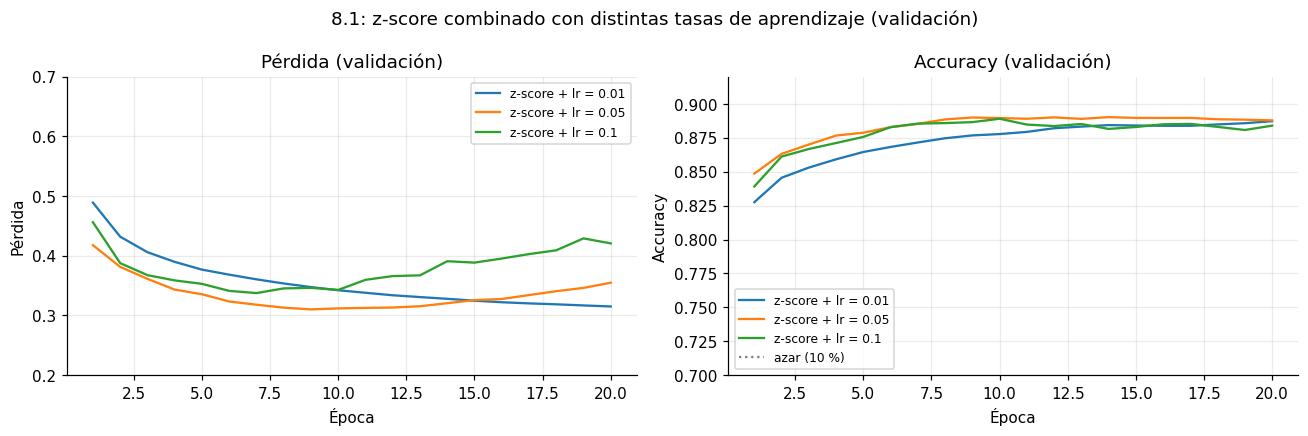


>>> Referencia elegida: zscore  (z-score + lr = 0.01)  pérdida val = 0.3151
↺ ref_s43: ya estaba entrenado en esta sesión (se reutiliza)
✔ ref_s43          acc val final = 0.8867 | pérdida val final = 0.3206 | 62 s
↺ ref_s44: ya estaba entrenado en esta sesión (se reutiliza)
✔ ref_s44          acc val final = 0.8932 | pérdida val final = 0.3058 | 64 s
Accuracy val: [0.8872 0.8867 0.8932] | media = 0.8890 | desv. = 0.0036
Pérdida val : [0.3151 0.3206 0.3058]
→ Nuevo umbral de ruido: 0.650 pp en accuracy | 0.0147 en pérdida


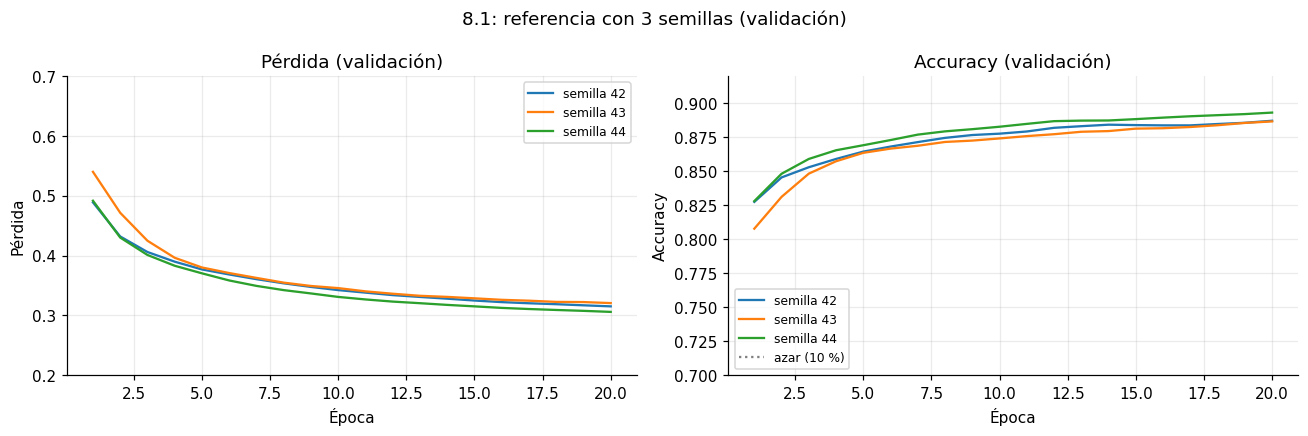

In [ ]:
# ============================================================
# 8.1 Referencia actualizada: z-score x tasa de aprendizaje
# ============================================================
DATOS_Z = (Xz_train, Y_train, Xz_val, Y_val)     # entradas estandarizadas (calculadas en E5, solo con train)

correr("z_lr0.05", lr=0.05, datos=DATOS_Z)
correr("z_lr0.1", lr=0.1, datos=DATOS_Z)

candidatos = ["zscore", "z_lr0.05", "z_lr0.1"]      # 'zscore' = z-score con lr 0.01 (E5)
et_c = etiquetas_de(candidatos, "lr", "z-score + lr = {}")
display(tabla_comparativa(candidatos, ref="base", etiquetas=et_c))   # Δ respecto del base ORIGINAL (min-max, lr 0.01)
graficar_curvas(candidatos, "8.1: z-score combinado con distintas tasas de aprendizaje (validación)",
                solo_val=True, etiquetas=et_c, ylim_perdida=(0.2, 0.7), ylim_acc=(0.7, 0.92))

# --- Regla de selección: menor pérdida de validación final ---
elegido = min(candidatos, key=lambda n: RESULTADOS[n]["historia"]["val_loss"][-1])
RESULTADOS["ref"] = RESULTADOS[elegido]              # 'ref' apunta al experimento elegido
LR_REF = RESULTADOS["ref"]["config"]["lr"]
print(f"\n>>> Referencia elegida: {elegido}  (z-score + lr = {LR_REF})  "
      f"pérdida val = {RESULTADOS['ref']['historia']['val_loss'][-1]:.4f}")

# --- Nuevo umbral de ruido con la referencia (3 semillas) ---
correr("ref_s43", lr=LR_REF, datos=DATOS_Z, semilla=43)
correr("ref_s44", lr=LR_REF, datos=DATOS_Z, semilla=44)
sem2 = ["ref", "ref_s43", "ref_s44"]
accs2 = np.array([RESULTADOS[n]["historia"]["val_accuracy"][-1] for n in sem2])
perd2 = np.array([RESULTADOS[n]["historia"]["val_loss"][-1] for n in sem2])
UMBRAL_RUIDO_PP = (accs2.max() - accs2.min()) * 100
UMBRAL_RUIDO_PERD = perd2.max() - perd2.min()
print(f"Accuracy val: {np.round(accs2, 4)} | media = {accs2.mean():.4f} | desv. = {accs2.std(ddof=1):.4f}")
print(f"Pérdida val : {np.round(perd2, 4)}")
print(f"→ Nuevo umbral de ruido: {UMBRAL_RUIDO_PP:.3f} pp en accuracy | {UMBRAL_RUIDO_PERD:.4f} en pérdida")
graficar_curvas(sem2, "8.1: referencia con 3 semillas (validación)", solo_val=True,
                etiquetas={"ref": "semilla 42", "ref_s43": "semilla 43", "ref_s44": "semilla 44"}, ylim_perdida=(0.2, 0.7),
                ylim_acc=(0.7, 0.92))


### 📝 Interpretación 8.1

La referencia queda fijada como **z-score + SGD con $\lambda=0,01$** (`ref`): accuracy de validación **88,72 %** y pérdida **0,3151**. Es la menor pérdida de las tres combinaciones y supera al modelo base original (min-max + $\lambda=0,01$) en **+1,54 pp** de accuracy y **−0,0491** de pérdida.

| Configuración | Accuracy val. | Pérdida val. | Lectura |
|---|---:|---:|---|
| z-score + $\lambda=0,01$ | 88,72 % | **0,3151** | referencia elegida |
| z-score + $\lambda=0,05$ | **88,78 %** | 0,3549 | peor pérdida |
| z-score + $\lambda=0,1$ | 88,39 % | 0,4208 | peor pérdida y más brecha |

Aumentar $\lambda$ con las entradas estandarizadas **no suma** la ventaja observada por separado: aunque $\lambda=0,05$ termina 0,06 pp arriba en accuracy, la diferencia es solo 0,09× el nuevo umbral y su pérdida aumenta 0,0398 (2,71× el umbral). Con $\lambda=0,1$ la pérdida aumenta aún más y la brecha train–val sube a 6,79 pp. Esto respalda que z-score ya aumenta la escala efectiva de las señales/gradientes; un paso mayor no mejora la convergencia final.

Las tres semillas de la referencia dan accuracy 88,72 %, 88,67 % y 89,32 %; por ello el ruido observado es **0,650 pp** y **0,0147** de pérdida. En las comparaciones siguientes, una diferencia menor o igual a esos valores se tratará como ruido, no como mejora.


## 8.2 Marco conceptual: tres funciones distintas

Conviene **no confundir** tres funciones que intervienen en una red:

| Función | Dónde actúa | Qué hace | Modelo base |
|---|---|---|---|
| **Activación** $f$ | En las neuronas de las **capas ocultas** | Introduce no linealidad y determina cómo fluye el gradiente hacia atrás. | ReLU |
| **Salida** $g$ | En la **última capa** | Convierte los valores de la red en la forma de la predicción (aquí, probabilidades por clase). | softmax |
| **Pérdida** $\mathcal{L}$ | Fuera de la red, al comparar $\hat{y}$ con $y$ | Mide el error que el entrenamiento minimiza. | entropía cruzada categórica |

Se sabe que la **sigmoide y la identidad no deben usarse como activación de capas ocultas** (sí pueden usarse como función de salida), que sigmoide y tanh **se saturan** en los extremos (pendiente casi nula → "la red no aprende") y que ReLU evita ese problema porque su gradiente no desaparece para valores positivos. En 8.3 **ponemos a prueba esas afirmaciones con datos**.

Lo importante no es memorizar fórmulas sino entender **los rangos y la forma de la curva** para anticipar qué efectos tendrá sobre la red. El siguiente gráfico muestra cada función y su **derivada** (la derivada es la "pendiente" que multiplica al gradiente en el *backpropagation*: si es casi 0, casi no llega señal a las capas anteriores).


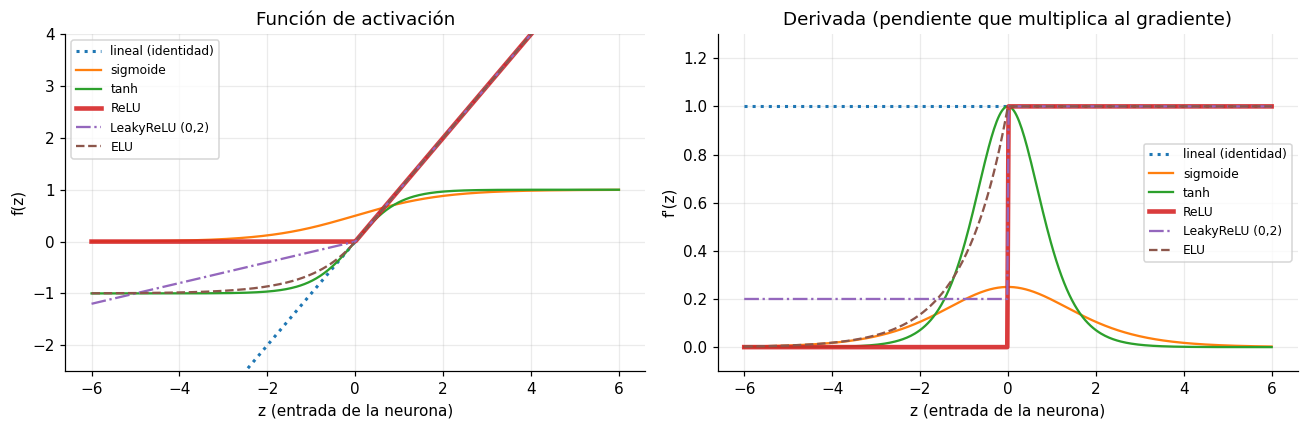

Valor máximo de la derivada: sigmoide = 0.25 | tanh = 1.0 | ReLU = 1


In [ ]:
# ============================================================
# 8.2 Funciones de activación y sus derivadas
# ============================================================
z = np.linspace(-6, 6, 400)
sig = 1 / (1 + np.exp(-z))
NEG = 0.2   # pendiente negativa de LeakyReLU (valor por defecto de keras.activations.leaky_relu)

funciones = {
    "lineal (identidad)": (z, np.ones_like(z)),
    "sigmoide": (sig, sig * (1 - sig)),
    "tanh": (np.tanh(z), 1 - np.tanh(z) ** 2),
    "ReLU": (np.maximum(0, z), (z > 0).astype(float)),
    "LeakyReLU (0,2)": (np.where(z > 0, z, NEG * z), np.where(z > 0, 1.0, NEG)),
    "ELU": (np.where(z > 0, z, np.exp(np.minimum(z, 0)) - 1), np.where(z > 0, 1.0, np.exp(np.minimum(z, 0)))),
}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
estilos = {"lineal (identidad)": dict(ls=":", lw=2), "ReLU": dict(lw=3, alpha=0.9),
           "ELU": dict(ls="--", lw=1.5), "LeakyReLU (0,2)": dict(ls="-.", lw=1.5)}
for nombre, (f, df) in funciones.items():
    ax[0].plot(z, f, label=nombre, **estilos.get(nombre, {}))
    ax[1].plot(z, df, label=nombre, **estilos.get(nombre, {}))
ax[0].set(xlabel="z (entrada de la neurona)", ylabel="f(z)", title="Función de activación", ylim=(-2.5, 4))
ax[1].set(xlabel="z (entrada de la neurona)", ylabel="f'(z)", title="Derivada (pendiente que multiplica al gradiente)", ylim=(-0.1, 1.3))
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("Valor máximo de la derivada: sigmoide =", round(float((sig * (1 - sig)).max()), 3),
      "| tanh =", round(float((1 - np.tanh(z) ** 2).max()), 3), "| ReLU = 1")


## 8.3 Comparación de funciones de activación (capas ocultas)

**Qué comparamos.** Solo cambia la activación de las **dos capas ocultas**; la salida (softmax), la pérdida (entropía cruzada), los datos (z-score), $\lambda$ (`LR_REF`), el lote (64), las épocas (20) y la semilla son los de la referencia `ref` (que usa ReLU).

| Función | Fórmula | Por qué la incluimos |
|---|---|---|
| lineal | $f(z) = z$ | **Control**: sin no linealidad, apilar capas equivale a *una sola* transformación lineal; muestra cuánto aporta la no linealidad. |
| sigmoide | $1/(1+e^{-z})$ | La activación clásica; se sabe que se satura. |
| tanh | $\tanh(z)$ | Versión centrada en 0 de la sigmoide; también se satura. |
| **ReLU** (referencia) | $\max(0, z)$ | La más usada; el gradiente no desaparece para $z>0$. |
| LeakyReLU | $z$ si $z>0$; $0{,}2\,z$ si no | Variante de ReLU con pendiente pequeña para $z<0$ (evita neuronas "muertas"). |
| ELU | $z$ si $z>0$; $e^{z}-1$ si no | Variante suave de ReLU con salidas negativas acotadas. |

**Diagnóstico previo (sin entrenar).** Para cada activación medimos la **magnitud media del gradiente** en cada capa, con los pesos recién inicializados y un lote de 512 imágenes. Si una activación "aplasta" el gradiente, las capas más lejanas de la salida recibirán gradientes mucho menores (*desvanecimiento del gradiente*). La razón `oculta_1 / salida` resume cuánto llega de señal a la primera capa en relación con la última.

**Hipótesis previas:**

| # | Hipótesis |
|---|---|
| H6 | El orden de desempeño será: lineal < sigmoide ≤ tanh < ReLU y variantes; la sigmoide será la más lenta (curva de aprendizaje más plana) por saturación. |
| H7 | ReLU, LeakyReLU y ELU serán indistinguibles entre sí dentro del ruido (≤ 1× umbral). |
| H8 | En el diagnóstico, la razón `oculta_1 / salida` será menor con sigmoide y tanh que con ReLU. |

**Limitaciones.** (1) Se usa la inicialización por defecto de Keras (Glorot/Xavier) para todas; una alternativa habitual es usar inicialización He para ReLU, pero variarla mezclaría dos factores. (2) Con **una sola $\lambda$** para todas las funciones, alguna (p. ej. sigmoide) podría haber rendido mejor con otra tasa. (3) Con solo 2 capas ocultas, el desvanecimiento del gradiente es leve comparado con redes profundas.

**Tiempo estimado:** 5 entrenamientos de ≈ 1 minuto.


In [ ]:
# ============================================================
# 8.3a Diagnóstico: magnitud del gradiente por capa, sin entrenar
# ============================================================
ACTIVACIONES = ["linear", "sigmoid", "tanh", "relu", "leaky_relu", "elu"]

def gradientes_iniciales(activacion, n=512):
    """Media del |gradiente| de los pesos de cada capa, con la red recién inicializada."""
    reiniciar_semillas()
    m = construir_modelo(activacion=activacion, nombre=f"diag_{activacion}")
    xb, yb = DATOS_Z[0][:n], DATOS_Z[1][:n]
    with tf.GradientTape() as cinta:
        pred = m(xb, training=False)
        perdida = tf.reduce_mean(keras.losses.categorical_crossentropy(yb, pred))
    grads = cinta.gradient(perdida, m.trainable_variables)
    kernels = grads[0::2]                     # variables = [kernel, bias] por capa -> tomamos los kernels
    return [float(tf.reduce_mean(tf.abs(g)).numpy()) for g in kernels]

filas = []
for a in ACTIVACIONES:
    g1, g2, g3 = gradientes_iniciales(a)
    filas.append({"activación": a, "oculta_1": g1, "oculta_2": g2, "salida": g3, "oculta_1 / salida": g1 / g3})
df_grad = pd.DataFrame(filas).set_index("activación")
display(df_grad.style.format({"oculta_1": "{:.2e}", "oculta_2": "{:.2e}", "salida": "{:.2e}", "oculta_1 / salida": "{:.3f}"}))


,oculta_1,oculta_2,salida,oculta_1 / salida
activación,,,,
linear,2.37e-02,3.65e-02,8.74e-02,0.271
sigmoid,8.11e-04,2.17e-03,1.45e-02,0.056
tanh,7.02e-03,1.04e-02,2.55e-02,0.275
relu,7.13e-03,1.02e-02,2.33e-02,0.307
leaky_relu,8.04e-03,1.20e-02,2.91e-02,0.277
elu,1.13e-02,1.69e-02,4.27e-02,0.265


↺ act_linear: ya estaba entrenado en esta sesión (se reutiliza)
✔ act_linear       acc val final = 0.8567 | pérdida val final = 0.4126 | 61 s
↺ act_sigmoid: ya estaba entrenado en esta sesión (se reutiliza)
✔ act_sigmoid      acc val final = 0.8392 | pérdida val final = 0.4553 | 64 s
↺ act_tanh: ya estaba entrenado en esta sesión (se reutiliza)
✔ act_tanh         acc val final = 0.8883 | pérdida val final = 0.3113 | 61 s
↺ ref: ya estaba entrenado en esta sesión (se reutiliza)
✔ ref              acc val final = 0.8872 | pérdida val final = 0.3151 | 62 s
↺ act_leaky_relu: ya estaba entrenado en esta sesión (se reutiliza)
✔ act_leaky_relu   acc val final = 0.8872 | pérdida val final = 0.3164 | 59 s
↺ act_elu: ya estaba entrenado en esta sesión (se reutiliza)
✔ act_elu          acc val final = 0.8881 | pérdida val final = 0.3130 | 62 s


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
linear,0.8567,0.8570,18,0.4126,0.0072,3.0729,61.4574,-3.05,4.6923,sólida,0.0975,6.6233,no
sigmoid,0.8392,0.8392,20,0.4553,-0.0044,3.2057,64.1146,-4.80,7.3846,sólida,0.1402,9.5218,no
tanh,0.8883,0.8883,20,0.3113,0.0151,3.0510,61.0208,0.11,0.1692,ruido,-0.0037,0.2546,no
relu (ref),0.8872,0.8872,20,0.3151,0.0197,3.0826,61.6519,0.00,0.0000,—,0.0000,0.0000,no
leaky_relu,0.8872,0.8872,20,0.3164,0.0137,2.9503,59.0054,0.00,0.0000,ruido,0.0013,0.0875,no
elu,0.8881,0.8881,20,0.3130,0.0142,3.1137,62.2732,0.09,0.1385,ruido,-0.0021,0.1424,no


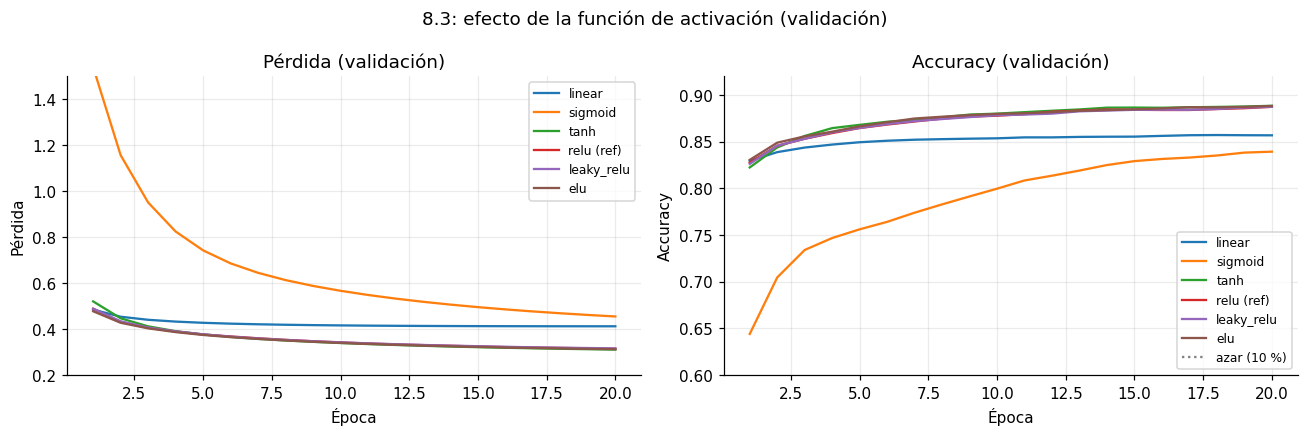

In [ ]:
# ============================================================
# 8.3b Entrenamiento con cada activación (referencia: ReLU = 'ref')
# ============================================================
nombres_act = []
for a in ACTIVACIONES:
    nombre = "ref" if a == "relu" else f"act_{a}"
    nombres_act.append(nombre)
    correr(nombre, activacion=a, lr=LR_REF, datos=DATOS_Z, callbacks=[keras.callbacks.TerminateOnNaN()])

et_act = {n: RESULTADOS[n]["config"]["activacion"] for n in nombres_act}
et_act["ref"] = "relu (ref)"
display(tabla_comparativa(nombres_act, ref="ref", etiquetas=et_act))
graficar_curvas(nombres_act, "8.3: efecto de la función de activación (validación)", solo_val=True,
                etiquetas=et_act, ylim_perdida=(0.2, 1.5), ylim_acc=(0.6, 0.92))


### 📝 Interpretación 8.3

**Gradientes iniciales.** La razón $|\nabla W_{oculta1}|/|\nabla W_{salida}|$ es **0,056 con sigmoide**, frente a 0,307 con ReLU; la señal que llega a la primera capa queda mucho más atenuada con sigmoide. Tanh (0,275), LeakyReLU (0,277) y ELU (0,265) conservan una proporción cercana a ReLU. Este diagnóstico se calcula antes de entrenar y con una tanda: describe la escala inicial, no prueba por sí solo todo el comportamiento posterior.

**Efecto en entrenamiento.** Lineal (85,67 %) y sigmoide (83,92 %) quedan claramente por debajo de ReLU (88,72 %): −3,05 pp (4,69× el ruido) y −4,80 pp (7,38×), respectivamente; las pérdidas también empeoran de forma sólida. Esto confirma que apilar capas lineales no añade no linealidad y que la sigmoide, por saturación y derivada máxima 0,25, aprende con mayor dificultad.

Tanh (88,83 %; pérdida 0,3113), LeakyReLU (88,72 %; 0,3164) y ELU (88,81 %; 0,3130) quedan dentro del ruido de la referencia en accuracy y pérdida. Por tanto, **no hay evidencia de que superen a ReLU** en esta arquitectura. Elegimos ReLU por ser simple, rápida y estándar; no porque haya ganado por una diferencia estadísticamente defendible.


## 8.4 Comparación de funciones de salida y de pérdida

**Qué comparamos.** Combinaciones de **función de salida** $g$ y **pérdida** $\mathcal{L}$, manteniendo ReLU en las capas ocultas y la configuración de la referencia:

| Nombre | Salida $g$ | Pérdida | Cómo interpreta el problema |
|---|---|---|---|
| **`ref`** | softmax | entropía cruzada categórica | Una distribución de probabilidad sobre 10 clases **mutuamente excluyentes**. |
| `sal_softmax_mse` | softmax | error cuadrático medio (MSE) | Igual salida, pero mide el error como distancia cuadrática al vector *one-hot*. |
| `sal_sigmoid_bce` | sigmoide | entropía cruzada binaria | 10 preguntas **independientes** "¿es de esta clase, sí o no?"; las probabilidades **no suman 1**. |
| `sal_lineal_mse` | lineal (identidad) | MSE | Una **regresión** hacia el vector *one-hot*; las salidas no son probabilidades. |

**Por qué se espera que la elección importe (teoría).**
- **Softmax + entropía cruzada** es la pareja natural para clases excluyentes: la softmax entrega probabilidades que suman 1 y la entropía cruzada solo penaliza la probabilidad asignada a la clase correcta, $-\log \hat{y}_{\text{correcta}}$. Un error grande produce un gradiente grande.
- **Softmax + MSE:** el gradiente del MSE atraviesa la derivada de la softmax, que se **achata cuando la salida está saturada** (probabilidades cercanas a 0 o 1). Así, justo cuando la red está muy segura de una clase equivocada, el gradiente se vuelve pequeño y el aprendizaje se frena.
- **Sigmoide + entropía cruzada binaria:** es la elección correcta para problemas **multietiqueta** (una imagen puede tener varias clases a la vez). Aquí cada imagen tiene exactamente una, así que la salida sigmoide no aprovecha esa restricción. La pérdida además se promedia sobre las 10 salidas, lo que reduce la magnitud del gradiente por clase.
- **Lineal + MSE:** trata las etiquetas como números; no impone que las salidas estén entre 0 y 1 ni sumen 1.

**Cómo comparar de forma justa.** Las **pérdidas de distintas funciones no son comparables entre sí** (tienen escalas distintas), así que la comparación se hace con el **accuracy de validación** y con la **velocidad** de las curvas de accuracy. Medimos el accuracy con la misma métrica para todas: el accuracy categórico (la clase con mayor salida contra la clase real), declarado explícitamente en `compilar_modelo` (así evitamos que Keras use accuracy binario con la entropía cruzada binaria, lo que inflaría el resultado).

**Hipótesis previa H9:** softmax + entropía cruzada tendrá el mejor accuracy y la convergencia más rápida; las tres alternativas quedarán por debajo, sobre todo con la misma $\lambda$ (sus gradientes son de menor magnitud).

**Limitación:** con la misma $\lambda$ para todas, una alternativa con gradientes más pequeños podría necesitar una tasa mayor para rendir igual; lo que medimos es el comportamiento **con la misma configuración**, no el máximo alcanzable por cada combinación.

**Tiempo estimado:** 3 entrenamientos de ≈ 1 minuto.


↺ sal_softmax_mse: ya estaba entrenado en esta sesión (se reutiliza)
✔ sal_softmax_mse  acc val final = 0.8327 | pérdida val final = 0.0242 | 66 s
↺ sal_sigmoid_bce: ya estaba entrenado en esta sesión (se reutiliza)
✔ sal_sigmoid_bce  acc val final = 0.8501 | pérdida val final = 0.0774 | 68 s
↺ sal_lineal_mse: ya estaba entrenado en esta sesión (se reutiliza)
✔ sal_lineal_mse   acc val final = 0.8344 | pérdida val final = 0.0304 | 63 s


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
softmax + entropía cruzada (ref),0.8872,0.8872,20,0.3151,0.0197,3.0826,61.6519,0.00,0.0000,—,0.0000,0.0000,no
softmax + MSE,0.8327,0.8327,20,0.0242,-0.0006,3.2898,65.7960,-5.45,8.3846,sólida,-0.2909,19.7565,no
sigmoide + entropía cruzada binaria,0.8501,0.8501,20,0.0774,-0.0006,3.3852,67.7031,-3.71,5.7077,sólida,-0.2377,16.1433,no
lineal + MSE,0.8344,0.8344,20,0.0304,-0.0044,3.1518,63.0366,-5.28,8.1231,sólida,-0.2847,19.3326,no


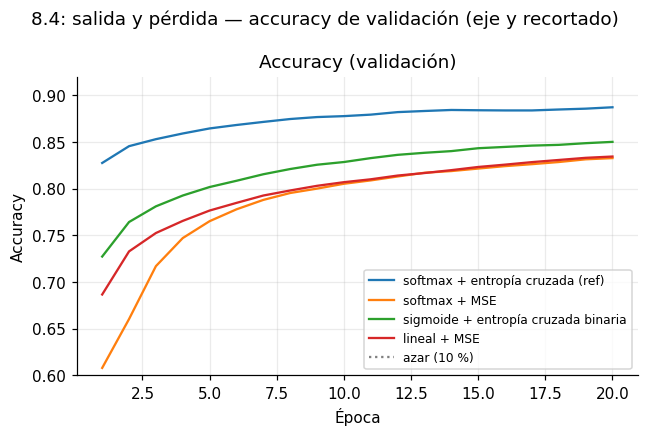

In [ ]:
# ============================================================
# 8.4 Funciones de salida y de pérdida
# ============================================================
correr("sal_softmax_mse", lr=LR_REF, datos=DATOS_Z, salida="softmax", perdida="mean_squared_error")
correr("sal_sigmoid_bce", lr=LR_REF, datos=DATOS_Z, salida="sigmoid", perdida="binary_crossentropy")
correr("sal_lineal_mse", lr=LR_REF, datos=DATOS_Z, salida="linear", perdida="mean_squared_error",
       callbacks=[keras.callbacks.TerminateOnNaN()])

nombres_sal = ["ref", "sal_softmax_mse", "sal_sigmoid_bce", "sal_lineal_mse"]
et_sal = {"ref": "softmax + entropía cruzada (ref)", "sal_softmax_mse": "softmax + MSE",
          "sal_sigmoid_bce": "sigmoide + entropía cruzada binaria", "sal_lineal_mse": "lineal + MSE"}
display(tabla_comparativa(nombres_sal, ref="ref", etiquetas=et_sal))
graficar_curvas(nombres_sal, "8.4: salida y pérdida — accuracy de validación (eje y recortado)",
                solo_val=True, etiquetas=et_sal, paneles=("accuracy",), ylim_acc=(0.6, 0.92))


### 📝 Interpretación 8.4

Se confirma H9: para estas 10 clases **mutuamente excluyentes**, `softmax + categorical_crossentropy` alcanza 88,72 %. Las tres alternativas quedan muy por debajo: softmax + MSE 83,27 % (−5,45 pp; 8,38× el ruido), sigmoide + BCE 85,01 % (−3,71 pp; 5,71×) y lineal + MSE 83,44 % (−5,28 pp; 8,12×). Ninguna diferencia es atribuible a las semillas.

No es válido comparar directamente los valores numéricos de pérdida entre objetivos distintos: MSE y BCE están en escalas diferentes. Por eso la comparación principal es el accuracy y las curvas de accuracy. La entropía cruzada categórica penaliza explícitamente la probabilidad asignada a la clase correcta y, combinada con softmax, produce un gradiente especialmente adecuado para elegir una sola de 10 categorías.

La combinación sigmoide + BCE funciona razonablemente, pero modela salidas independientes (válida si una imagen pudiera contener varias etiquetas); aquí las clases son excluyentes y sus probabilidades no quedan forzadas a sumar uno. La salida lineal + MSE tampoco representa probabilidades. No hubo NaN: las alternativas fueron estables, pero menos apropiadas y menos precisas.


## 8.5 Tabla resumen y decisiones

Tabla única con todos los experimentos de esta sección, ordenada por accuracy de validación, y luego la selección final justificada.


,acc val final,mejor acc val,época del mejor,pérdida val final,brecha acc (train-val),s / época,tiempo total (s),Δ acc vs ref (pp),× umbral acc,lectura,Δ pérdida val,× umbral pérdida,divergió (NaN)
experimento,,,,,,,,,,,,,
ref_s44,0.8932,0.8932,20,0.3058,0.0133,3.2126,64.2510,0.60,0.9231,ruido,-0.0092,0.6281,no
act_tanh,0.8883,0.8883,20,0.3113,0.0151,3.0510,61.0208,0.11,0.1692,ruido,-0.0037,0.2546,no
act_elu,0.8881,0.8881,20,0.3130,0.0142,3.1137,62.2732,0.09,0.1385,ruido,-0.0021,0.1424,no
act_leaky_relu,0.8872,0.8872,20,0.3164,0.0137,2.9503,59.0054,0.00,0.0000,ruido,0.0013,0.0875,no
ref,0.8872,0.8872,20,0.3151,0.0197,3.0826,61.6519,0.00,0.0000,—,0.0000,0.0000,no
ref_s43,0.8867,0.8867,20,0.3206,0.0224,3.0974,61.9480,-0.05,0.0769,ruido,0.0055,0.3719,no
act_linear,0.8567,0.8570,18,0.4126,0.0072,3.0729,61.4574,-3.05,4.6923,sólida,0.0975,6.6233,no
sal_sigmoid_bce,0.8501,0.8501,20,0.0774,-0.0006,3.3852,67.7031,-3.71,5.7077,sólida,-0.2377,16.1433,no
act_sigmoid,0.8392,0.8392,20,0.4553,-0.0044,3.2057,64.1146,-4.80,7.3846,sólida,0.1402,9.5218,no


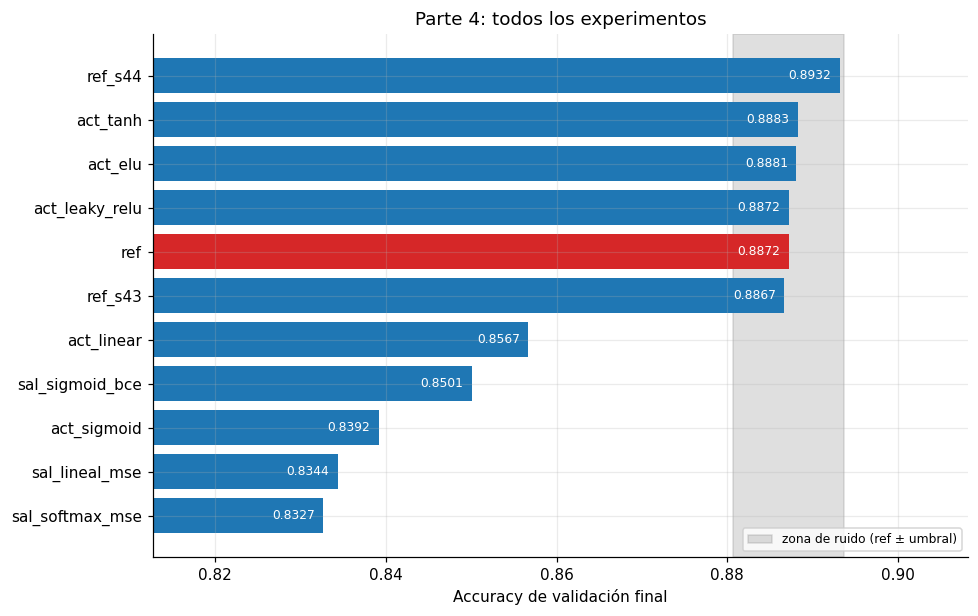

✔ 27 experimentos guardados en resultados_ep1.json


In [ ]:
# ============================================================
# 8.5 Resumen de la sección
# ============================================================
todos4 = ["ref", "ref_s43", "ref_s44"] \
       + [n for n in nombres_act if n != "ref"] \
       + [n for n in nombres_sal if n != "ref"]
todos4 = [n for n in todos4 if n in RESULTADOS]

tabla4 = tabla_comparativa(todos4, ref="ref").sort_values("acc val final", ascending=False)
display(tabla4)

# --- Gráfico: accuracy de validación final ---
orden = tabla4.index.tolist()[::-1]
valores = tabla4.loc[orden, "acc val final"].values
ref_acc = RESULTADOS["ref"]["historia"]["val_accuracy"][-1]

candidatos_x = valores[valores > 0.5]
xmin = candidatos_x.min() - 0.02 if len(candidatos_x) else 0.0
xmax = min(1.0, valores.max() + 0.015)

fig, ax = plt.subplots(figsize=(9, 0.4 * len(orden) + 1.3))
ax.axvspan(ref_acc - UMBRAL_RUIDO_PP / 100, ref_acc + UMBRAL_RUIDO_PP / 100,
           color="gray", alpha=0.25, label="zona de ruido (ref ± umbral)")
ax.barh(orden, valores, color=["C3" if n == "ref" else "C0" for n in orden])
for y_pos, v in enumerate(valores):
    if v < xmin:
        ax.text(xmin + 0.001, y_pos, f"{v:.1%} (fuera de escala)", va="center", fontsize=8, color="crimson")
    else:
        ax.text(v - 0.001, y_pos, f"{v:.4f}", va="center", ha="right", fontsize=8, color="white")
ax.set_xlim(xmin, xmax)
ax.set_xlabel("Accuracy de validación final")
ax.set_title("Resumen: funciones de activación y de salida (Sección 8)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

guardar_resultados()


### 📝 Conclusiones de la Sección 8 y selección final

La configuración que pasa a la siguiente sección (regularización) es: entradas **z-score** calculadas solo con entrenamiento, MLP `784 → 128 → 64 → 10`, activación **ReLU**, salida **softmax**, pérdida **entropía cruzada categórica**, optimizador SGD, $\lambda=0,01$, batch 64 y 20 épocas. Su referencia es 88,72 % de accuracy de validación y 0,3151 de pérdida.

Las variantes tanh, LeakyReLU y ELU no muestran una mejora que exceda 0,650 pp o 0,0147 de pérdida; se reportan como ruido. En cambio, lineal, sigmoide y las tres parejas salida–pérdida alternativas empeoran entre 3,05 y 5,45 pp, evidencia sólida. La selección se fundamenta tanto en la coherencia con el problema multiclase excluyente como en el experimento controlado, no en una diferencia marginal de una sola corrida.

La pérdida se interpretó solo dentro de una misma función objetivo; para comparar funciones distintas se usó accuracy. La siguiente sección probará regularización y optimización conservando esta referencia y variando un factor por vez.


---
# 9. Regularización y optimización

La referencia de la sección anterior logra buen desempeño, pero presenta una brecha entre entrenamiento y validación. Evaluaremos si técnicas de regularización u optimización mejoran la generalización, cambiando una sola decisión por experimento y manteniendo el test intacto.

La referencia usa entradas z-score, MLP 128–64, ReLU, softmax, entropía cruzada categórica, SGD con tasa 0,01, batch 64 y 20 épocas. Las diferencias se interpretan con los umbrales ya medidos: 0,650 pp de accuracy y 0,0147 de pérdida.


In [ ]:
# ============================================================
# 9.1 Funciones para regularización y optimización
# ============================================================
# Las opciones quedan desactivadas por defecto y no alteran los resultados anteriores.

def construir_modelo_avanzado(unidades=(128, 64), activacion="relu", salida="softmax",
                              dropout=0.0, l2=0.0, batchnorm=False, nombre="mlp_avanzado"):
    regularizador = keras.regularizers.l2(l2) if l2 else None
    modelo = keras.Sequential(name=nombre)
    modelo.add(keras.Input(shape=(NUM_ENTRADAS,), name="entrada"))
    for k, u in enumerate(unidades, start=1):
        if batchnorm:
            modelo.add(keras.layers.Dense(u, activation=None, use_bias=False,
                      kernel_regularizer=regularizador, name=f"oculta_{k}"))
            modelo.add(keras.layers.BatchNormalization(name=f"bn_{k}"))
            modelo.add(keras.layers.Activation(activacion, name=f"act_{k}"))
        else:
            modelo.add(keras.layers.Dense(u, activation=activacion,
                      kernel_regularizer=regularizador, name=f"oculta_{k}"))
        if dropout:
            modelo.add(keras.layers.Dropout(dropout, name=f"dropout_{k}"))
    modelo.add(keras.layers.Dense(NUM_CLASES, activation=salida, name="salida"))
    return modelo

def crear_optimizador(nombre, lr):
    if nombre == "sgd":
        return keras.optimizers.SGD(learning_rate=lr)
    if nombre == "adam":
        return keras.optimizers.Adam(learning_rate=lr)
    raise ValueError("optimizador debe ser 'sgd' o 'adam'")

def entrenar_avanzado(nombre, unidades=(128, 64), activacion="relu", salida="softmax",
                      perdida="categorical_crossentropy", lr=LR_REF, optimizador="sgd",
                      dropout=0.0, l2=0.0, batchnorm=False, batch_size=BATCH_BASE,
                      epocas=EPOCAS_BASE, semilla=SEED, callbacks=None, verbose=0):
    reiniciar_semillas(semilla)
    modelo = construir_modelo_avanzado(unidades, activacion, salida, dropout, l2, batchnorm, nombre)
    modelo.compile(optimizer=crear_optimizador(optimizador, lr), loss=perdida,
                   metrics=[keras.metrics.CategoricalAccuracy(name="accuracy")])
    t0 = time.perf_counter()
    hist = modelo.fit(Xz_train, Y_train, validation_data=(Xz_val, Y_val),
                      epochs=epocas, batch_size=batch_size, shuffle=True,
                      callbacks=callbacks or [], verbose=verbose)
    duracion = time.perf_counter() - t0
    RESULTADOS[nombre] = {
        "config": dict(unidades=tuple(unidades), activacion=activacion, salida=salida,
                       perdida=perdida, lr=lr, optimizador=optimizador, dropout=dropout,
                       l2=l2, batchnorm=batchnorm, batch_size=batch_size, epocas=epocas,
                       semilla=semilla, datos="z-score"),
        "historia": hist.history, "tiempo_s": duracion,
        "iter_por_epoca": int(np.ceil(len(Xz_train) / batch_size)),
    }
    return modelo

def correr_avanzado(nombre, forzar=False, **kwargs):
    if nombre in RESULTADOS and not forzar:
        print(f"↺ {nombre}: ya estaba entrenado (se reutiliza)")
        return None
    modelo = entrenar_avanzado(nombre, **kwargs)
    r = resumir(nombre)
    print(f"✔ {nombre:<18} acc val final = {r['acc val (final)']:.4f} | "
          f"pérdida val final = {r['pérdida val (final)']:.4f} | {r['tiempo total (s)']:.0f} s")
    return modelo

def tabla_seleccion_regularizacion(nombres):
    filas = []
    for n in nombres:
        h, r = RESULTADOS[n]["historia"], resumir(n)
        i_loss = int(np.argmin(h["val_loss"]))
        filas.append({"experimento": n, "acc val final": r["acc val (final)"],
                      "mejor acc val": max(h["val_accuracy"]),
                      "mejor pérdida val": h["val_loss"][i_loss],
                      "época mejor pérdida": i_loss + 1, "épocas ejecutadas": len(h["loss"]),
                      "brecha acc final": r["brecha acc (train - val)"],
                      "s / época": r["s / época"], "tiempo total (s)": r["tiempo total (s)"]})
    return pd.DataFrame(filas).set_index("experimento").round(4)

print("Funciones de regularización y optimización definidas.")


Funciones de Parte 5 definidas.


## 9.2 Diseño experimental

| Experimento | Único cambio respecto de la referencia | Hipótesis |
|---|---|---|
| Dropout | dropout = 0,20 después de cada capa oculta | Reduce coadaptación; si es excesivo, puede subajustar. |
| L2 | L2 = 1e-4 en los kernels densos | Penaliza pesos grandes y favorece una solución más simple. |
| Batch normalization | normalización antes de cada ReLU | Puede estabilizar activaciones y acelerar la convergencia. |
| Adam | optimizador Adam con tasa 0,001 | Sus tasas adaptativas pueden mejorar la convergencia. |
| Early stopping | máximo 60 épocas, paciencia 5 | Busca detener el sobreajuste y ahorrar costo. |

No se combinan técnicas todavía. El test no participa.


✔ reg_dropout_020    acc val final = 0.8855 | pérdida val final = 0.3162 | 85 s
✔ reg_l2_1e4         acc val final = 0.8866 | pérdida val final = 0.3487 | 74 s
✔ reg_batchnorm      acc val final = 0.8913 | pérdida val final = 0.3132 | 75 s
✔ opt_adam           acc val final = 0.8885 | pérdida val final = 0.4404 | 87 s
✔ reg_earlystop      acc val final = 0.8897 | pérdida val final = 0.3092 | 111 s


,acc val final,mejor acc val,mejor pérdida val,época mejor pérdida,épocas ejecutadas,brecha acc final,s / época,tiempo total (s)
experimento,,,,,,,,
reg_earlystop,0.8897,0.8897,0.3092,31,32,0.0357,3.4548,110.5535
reg_batchnorm,0.8913,0.8913,0.3126,19,20,0.0338,3.7617,75.2337
ref,0.8872,0.8872,0.3151,20,20,0.0197,3.0826,61.6519
reg_dropout_020,0.8855,0.8863,0.3162,20,20,-0.0108,4.2686,85.3713
opt_adam,0.8885,0.8885,0.3355,6,20,0.0585,4.3559,87.1178
reg_l2_1e4,0.8866,0.8866,0.3487,20,20,0.0202,3.7162,74.3230


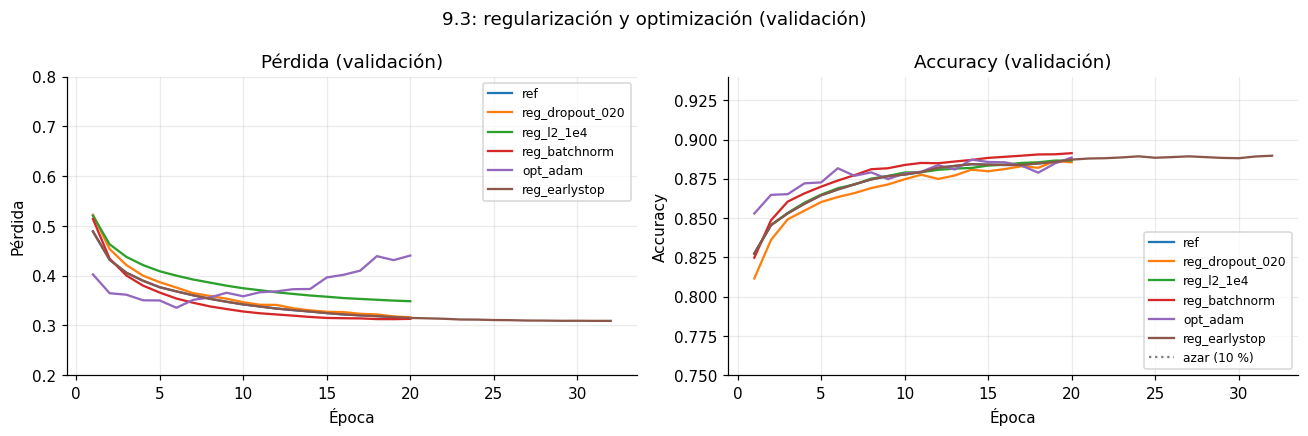

✔ 32 experimentos guardados en resultados_ep1.json


In [ ]:
# ============================================================
# 9.3 Experimentos de regularización y optimización
# ============================================================
# La referencia heredada se llama "ref" y no se vuelve a entrenar.

correr_avanzado("reg_dropout_020", dropout=0.20)
correr_avanzado("reg_l2_1e4", l2=1e-4)
correr_avanzado("reg_batchnorm", batchnorm=True)
correr_avanzado("opt_adam", optimizador="adam", lr=0.001)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", mode="min", patience=5, min_delta=0.001, restore_best_weights=True
)
correr_avanzado("reg_earlystop", epocas=60, callbacks=[early_stop])

nombres5 = ["ref", "reg_dropout_020", "reg_l2_1e4", "reg_batchnorm", "opt_adam", "reg_earlystop"]
display(tabla_seleccion_regularizacion(nombres5).sort_values("mejor pérdida val"))
graficar_curvas(nombres5, "9.3: regularización y optimización (validación)",
                solo_val=True, ylim_acc=(0.75, 0.94), ylim_perdida=(0.2, 0.8))
guardar_resultados()


### 📝 Interpretación de la Sección 9

| Técnica | Mejor pérdida val. (época) | Mejor accuracy val. | Brecha final train–val | Lectura frente a `ref` |
|---|---:|---:|---:|---|
| Referencia (sin técnica) | 0,3151 (20) | 88,72 % | 1,97 pp | referencia |
| Dropout 0,20 | 0,3162 (20) | 88,63 % | −1,08 pp | accuracy y pérdida: ruido |
| L2 = 1e-4 | 0,3487 (20) | 88,66 % | 2,02 pp | pérdida **peor** en 0,0336 (2,29× el ruido) |
| Batch normalization | 0,3126 (19) | **89,13 %** | 3,38 pp | +0,41 pp y −0,0025: ambos dentro del ruido |
| Adam (lr = 0,001) | 0,3355 (6) | 88,85 % | 5,85 pp | accuracy: ruido; pérdida mínima peor en 0,0204 (1,39×) |
| Early stopping | **0,3092 (31)** | 88,97 % | 3,57 pp | +0,25 pp y −0,0059: ambos dentro del ruido |

**Regularización.** Dropout reduce la brecha hasta hacerla negativa, pero no mejora la validación y cuesta 85,4 s frente a 61,7 s de la referencia. En esta red el 20 % parece limitar levemente la capacidad antes que corregir un sobreajuste relevante. L2 es la única alternativa claramente perjudicial en pérdida: su penalización es demasiado fuerte para esta configuración. Batch normalization logra el accuracy máximo y una pérdida ligeramente menor, pero sus diferencias son 0,63× y 0,17× los umbrales respectivos; no constituyen evidencia de mejora real y además tarda 22 % más por época.

**Optimización.** Adam inicia con la mayor accuracy, pero su pérdida alcanza el mínimo en la época 6 (0,3355), luego sube hasta 0,4404 y la brecha final llega a 5,85 pp. El gráfico muestra estancamiento de accuracy y deterioro de pérdida: con esta tasa y estos datos, Adam no generaliza mejor que SGD. No se ajusta su tasa aquí porque eso sería otro experimento, no una comparación controlada.

**Early stopping.** Se detuvo tras 32 épocas y restauró los pesos de la época 31, con la menor pérdida observada (0,3092). Evitó 28 de las 60 épocas máximas; usando su costo medio, equivale a aproximadamente 97 s que no fue necesario entrenar. Sin embargo, no debe presentarse como una mejora causal frente a la referencia de 20 épocas: esta corrida tuvo hasta 32 épocas efectivas, además del callback. Su resultado está dentro del ruido, pero demuestra que el criterio de detención puede seleccionar un punto de la curva y limitar el costo.

**Decisión para la siguiente etapa.** No hay evidencia suficiente para añadir Dropout, L2, BatchNorm ni reemplazar SGD por Adam: conservamos la configuración simple de la sección anterior (z-score, ReLU, softmax, entropía cruzada, SGD 0,01, batch 64). Early stopping se reservará como criterio de parada del reentrenamiento final, no como justificación de una mejora en esta comparación. Una etapa posterior variará únicamente la arquitectura.
